 <div class="alert alert-block alert-info">
<font size="5"><b>1:</b> Importing all the necessary libraries which we would require in analysing.</font>
</div>

In [316]:
import warnings
warnings.filterwarnings('ignore')

In [317]:
#importing all the necessary library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

 <div class="alert alert-block alert-info">
<font size="5"><b>1.1:</b> Reading the Application data csv file and creating dataframe.</font>
</div>

In [318]:
df1=pd.read_csv("application_data.csv")


In [319]:
# Having a overview of application data
df1.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [320]:
df1.shape

(307511, 122)

In [321]:
df1.info(verbose=True)
#106 numerical 16 cateogarical variables in df1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA


<div class="alert alert-block alert-success">
<font size="5"><b>Inference:</b> Lot of attribute in df1 has object type, we would  need to typecast it.</font>
</div>

 <div class="alert alert-block alert-info">
<font size="5"><b>1.1.1:</b> Analysing  target variable first to be ensured that data provided to us is correct as our analysis will greatly be dependent of TARGET variable
    </font>
</div> 

In [322]:
df1.TARGET.dtype

dtype('int64')

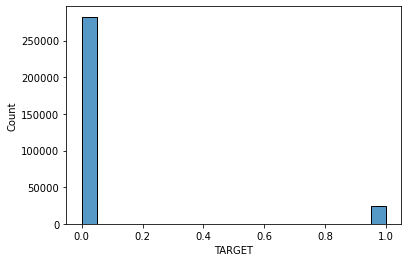

In [323]:
sns.histplot(df1.TARGET)
plt.show()

In [324]:
#checking ratio for target variable between 0 and 1
df1[df1.TARGET==0].shape[0]/df1[df1.TARGET==1].shape[0]

11.387150050352467

#### 
<div class="alert alert-block alert-success">
<font size="5"><b>Inference:</b> Lot of data imbalance between o and 1 in target variable.We need to create dataframe for these two seprately
    </font >
</div>


In [325]:
df1[df1.TARGET>0].describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,24825.000000,24825.0,24825.000000,2.482500e+04,2.482500e+04,24825.000000,2.480400e+04,24825.000000,24825.000000,24825.000000,...,24825.000000,24825.000000,24825.000000,24825.000000,20533.000000,20533.000000,20533.000000,20533.000000,20533.000000,20533.000000
mean,277449.167936,1.0,0.463807,1.656118e+05,5.577785e+05,26481.744290,4.889724e+05,0.019131,-14884.828077,42394.675448,...,0.005720,0.000483,0.000524,0.000564,0.006672,0.008036,0.034919,0.227926,0.259923,2.028783
std,102383.123458,0.0,0.756903,7.466770e+05,3.464332e+05,12450.676999,3.116365e+05,0.011905,4192.844583,119484.634253,...,0.075416,0.021981,0.022878,0.023741,0.084926,0.106682,0.203941,0.745116,0.643789,1.934063
min,100002.000000,1.0,0.000000,2.565000e+04,4.500000e+04,2722.500000,4.500000e+04,0.000533,-25168.000000,-16069.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189555.000000,1.0,0.000000,1.125000e+05,2.844000e+05,17361.000000,2.385000e+05,0.009630,-18037.000000,-2156.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,276291.000000,1.0,0.000000,1.350000e+05,4.975200e+05,25263.000000,4.500000e+05,0.018634,-14282.000000,-1034.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,366050.000000,1.0,1.000000,2.025000e+05,7.333155e+05,32976.000000,6.750000e+05,0.025164,-11396.000000,-379.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456254.000000,1.0,11.000000,1.170000e+08,4.027680e+06,149211.000000,3.600000e+06,0.072508,-7678.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,4.000000,6.000000,17.000000,19.000000,22.000000


In [326]:
#total applicant having trouble in paying=24825 and without trouble 282686
df1.TARGET.value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64


<div class="alert alert-block alert-info">
<b>1.2:</b> Data cleansing of application data which is df1 dataframe.
</div>

 <div class="alert alert-block alert-info">
<font size="5"><b>1.2:</b> NULL CHECK.</font>
</div>

#### MISSING ARE ALSO CATEOGARISED as Nan

In [327]:
df1.isnull().sum()#target has no null which is good

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

 <div class="alert alert-block alert-info">
<font size="5"><b>1.2:</b> NULL CHECK calculating NULL percentage for each column in application data (df1 data frame)</font>
</div>

In [328]:
x=df1.columns.tolist()
def perc(i):
    null_values=df1[i].isnull().sum()
    total_value=df1[i].shape[0]
    null_percentage=null_values/total_value
    return null_percentage
for i in x:
    print(i,perc(i))

SK_ID_CURR 0.0
TARGET 0.0
NAME_CONTRACT_TYPE 0.0
CODE_GENDER 0.0
FLAG_OWN_CAR 0.0
FLAG_OWN_REALTY 0.0
CNT_CHILDREN 0.0
AMT_INCOME_TOTAL 0.0
AMT_CREDIT 0.0
AMT_ANNUITY 3.9022994299390916e-05
AMT_GOODS_PRICE 0.0009040327012692228
NAME_TYPE_SUITE 0.004201475719567756
NAME_INCOME_TYPE 0.0
NAME_EDUCATION_TYPE 0.0
NAME_FAMILY_STATUS 0.0
NAME_HOUSING_TYPE 0.0
REGION_POPULATION_RELATIVE 0.0
DAYS_BIRTH 0.0
DAYS_EMPLOYED 0.0
DAYS_REGISTRATION 0.0
DAYS_ID_PUBLISH 0.0
OWN_CAR_AGE 0.6599081008484249
FLAG_MOBIL 0.0
FLAG_EMP_PHONE 0.0
FLAG_WORK_PHONE 0.0
FLAG_CONT_MOBILE 0.0
FLAG_PHONE 0.0
FLAG_EMAIL 0.0
OCCUPATION_TYPE 0.31345545362604915
CNT_FAM_MEMBERS 6.503832383231819e-06
REGION_RATING_CLIENT 0.0
REGION_RATING_CLIENT_W_CITY 0.0
WEEKDAY_APPR_PROCESS_START 0.0
HOUR_APPR_PROCESS_START 0.0
REG_REGION_NOT_LIVE_REGION 0.0
REG_REGION_NOT_WORK_REGION 0.0
LIVE_REGION_NOT_WORK_REGION 0.0
REG_CITY_NOT_LIVE_CITY 0.0
REG_CITY_NOT_WORK_CITY 0.0
LIVE_CITY_NOT_WORK_CITY 0.0
ORGANIZATION_TYPE 0.0
EXT_SOURCE_1 0.

<div class="alert alert-block alert-success">
<b>Inference:</b>As we can see lot of missing value are greater than 50%. So we need to remove all such attributes
</div>

 <div class="alert alert-block alert-info">
<font size="5"> Count of nulls in each column</font>
</div>


In [329]:
y=df1.columns.tolist()
def null_val(i):
    null_values=df1[i].isnull().sum()
    total_value=df1[i].shape[0]
    null_percentage=null_values/total_value
    return null_values
for i in y:
    print(i,null_val(i))

SK_ID_CURR 0
TARGET 0
NAME_CONTRACT_TYPE 0
CODE_GENDER 0
FLAG_OWN_CAR 0
FLAG_OWN_REALTY 0
CNT_CHILDREN 0
AMT_INCOME_TOTAL 0
AMT_CREDIT 0
AMT_ANNUITY 12
AMT_GOODS_PRICE 278
NAME_TYPE_SUITE 1292
NAME_INCOME_TYPE 0
NAME_EDUCATION_TYPE 0
NAME_FAMILY_STATUS 0
NAME_HOUSING_TYPE 0
REGION_POPULATION_RELATIVE 0
DAYS_BIRTH 0
DAYS_EMPLOYED 0
DAYS_REGISTRATION 0
DAYS_ID_PUBLISH 0
OWN_CAR_AGE 202929
FLAG_MOBIL 0
FLAG_EMP_PHONE 0
FLAG_WORK_PHONE 0
FLAG_CONT_MOBILE 0
FLAG_PHONE 0
FLAG_EMAIL 0
OCCUPATION_TYPE 96391
CNT_FAM_MEMBERS 2
REGION_RATING_CLIENT 0
REGION_RATING_CLIENT_W_CITY 0
WEEKDAY_APPR_PROCESS_START 0
HOUR_APPR_PROCESS_START 0
REG_REGION_NOT_LIVE_REGION 0
REG_REGION_NOT_WORK_REGION 0
LIVE_REGION_NOT_WORK_REGION 0
REG_CITY_NOT_LIVE_CITY 0
REG_CITY_NOT_WORK_CITY 0
LIVE_CITY_NOT_WORK_CITY 0
ORGANIZATION_TYPE 0
EXT_SOURCE_1 173378
EXT_SOURCE_2 660
EXT_SOURCE_3 60965
APARTMENTS_AVG 156061
BASEMENTAREA_AVG 179943
YEARS_BEGINEXPLUATATION_AVG 150007
YEARS_BUILD_AVG 204488
COMMONAREA_AVG 214865
ELE

In [330]:
df1.shape

(307511, 122)

 <div class="alert alert-block alert-info">
<font size="5"> Removing all columns having null, blank value which are greater than 50% missing in column (df1 data frame)</font>
</div>

In [331]:
x=df1.columns.tolist()
for i in x:
    if(perc(i)>.45):
        df1.drop([i],axis=1,inplace=True)
    else:
        pass


<div class="alert alert-block alert-danger">
<b>why 45%:</b> Ideally should take 50%, but seeing the data there are 49% close to 50 % as these many null values will reduce the quality of analysis.
</div>
 Out of 122 columns,now 73 are left after removal.

 <div class="alert alert-block alert-info">
<font size="5"> Lets handle missing values in the following columns</font>
</div>
    AMT_REQ_CREDIT_BUREAU_HOUR 0.14, 
    
    AMT_REQ_CREDIT_BUREAU_DAY 0.14, 
    
    AMT_REQ_CREDIT_BUREAU_WEEK 0.14,
    
    AMT_REQ_CREDIT_BUREAU_MON 0.14, 
    
    AMT_REQ_CREDIT_BUREAU_QRT 0.14, 
    
    AMT_REQ_CREDIT_BUREAU_YEAR 0.14, 
    
    OCCUPATION_TYPE 0.31
    
    AMT_ANNUITY 3.9022994299390916e-05
    
    AMT_GOODS_PRICE 0.0009040327012692228
    
    NAME_TYPE_SUITE 0.004201475719567756
    
    CNT_FAM_MEMBERS 6.503832383231819e-06
    
    EXT_SOURCE_2 0.0021462646864665006
    
    EXT_SOURCE_3 0.19825307062186392
    
    OBS_30_CNT_SOCIAL_CIRCLE 0.0033202064316398437
    
    DEF_30_CNT_SOCIAL_CIRCLE 0.0033202064316398437
    
    OBS_60_CNT_SOCIAL_CIRCLE 0.0033202064316398437
    
    DEF_60_CNT_SOCIAL_CIRCLE 0.0033202064316398437
    
    DAYS_LAST_PHONE_CHANGE 3.2519161916159095e-06

<div class="alert alert-block alert-success">
<b>Handling missing value:</b>Imputing mode and median to nan values for respective column, to handle missing data
</div>



In [332]:
print(df1['AMT_REQ_CREDIT_BUREAU_YEAR'].mode())
print(df1['AMT_REQ_CREDIT_BUREAU_HOUR'].mode())
print(df1['AMT_REQ_CREDIT_BUREAU_DAY'].mode())
print(df1['AMT_REQ_CREDIT_BUREAU_WEEK'].mode())
print(df1['AMT_REQ_CREDIT_BUREAU_MON'].mode())
print(df1['AMT_REQ_CREDIT_BUREAU_QRT'].mode())
print(df1['AMT_ANNUITY'].median())
print(df1['AMT_GOODS_PRICE'].median())
print(df1['CNT_FAM_MEMBERS'].median())
print( df1['EXT_SOURCE_2'].median())
print(df1['EXT_SOURCE_3'].median())




0    0.0
dtype: float64
0    0.0
dtype: float64
0    0.0
dtype: float64
0    0.0
dtype: float64
0    0.0
dtype: float64
0    0.0
dtype: float64
24903.0
450000.0
2.0
0.5659614260608526
0.5352762504724826


In [333]:
#filling null with median value
df1['AMT_ANNUITY']=df1['AMT_ANNUITY'].fillna(df1['AMT_ANNUITY'].median(),inplace=False)# median because its an numerical type amount data and mean would have create data imbalance
df1['AMT_GOODS_PRICE']=df1['AMT_GOODS_PRICE'].fillna(df1['AMT_GOODS_PRICE'].median(),inplace=False)# median because its an numerical type amount data and mean would have create data imbalance
df1['CNT_FAM_MEMBERS']=df1['CNT_FAM_MEMBERS'].fillna(df1['CNT_FAM_MEMBERS'].median(),inplace=False)# median because its an numerical type amount data and mean would have create data imbalance
df1['EXT_SOURCE_2']= df1['EXT_SOURCE_2'].fillna(df1['EXT_SOURCE_2'].median(),inplace=False)# median because its an numerical type amount data and mean would have create data imbalance
df1['EXT_SOURCE_3']=df1['EXT_SOURCE_3'].fillna(df1['EXT_SOURCE_3'].median(),inplace=False)# median because its an numerical type amount data and mean would have create data imbalance


<div class="alert alert-block alert-info">
<font size="5"> <b>1.3:</b>
    
  Standardising the Value 
    </font>
</div>


<div class="alert alert-block alert-success">
Data types and Data
</div>



 <div class="alert alert-block alert-info">
<font size="5"> Check all unique values in df1 </font>
</div>

In [334]:
x=df1.columns.tolist()
for i in x:
    print(str.capitalize(i),df1[i].unique())

Sk_id_curr [100002 100003 100004 ... 456253 456254 456255]
Target [1 0]
Name_contract_type ['Cash loans' 'Revolving loans']
Code_gender ['M' 'F' 'XNA']
Flag_own_car ['N' 'Y']
Flag_own_realty ['Y' 'N']
Cnt_children [ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14]
Amt_income_total [202500.  270000.   67500.  ...  96768.  546250.5 113062.5]
Amt_credit [ 406597.5 1293502.5  135000.  ...  181989.   743863.5 1391130. ]
Amt_annuity [24700.5 35698.5  6750.  ... 71986.5 58770.  77809.5]
Amt_goods_price [ 351000.  1129500.   135000.  ...  453465.   143977.5  743863.5]
Name_type_suite ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']
Name_income_type ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
Name_education_type ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Name_family_status ['Single / not married' 'Married' 'Ci

Obs_60_cnt_social_circle [  2.   1.   0.   4.   8.  10.  nan   7.   3.   6.   5.  12.   9.  13.
  11.  14.  21.  15.  22.  16.  20.  25.  17.  19.  18.  24.  23.  28.
  29.  27.  47. 344.  30.  26.]
Def_60_cnt_social_circle [ 2.  0.  1. nan  3.  5.  4.  7. 24.  6.]
Days_last_phone_change [-1134.  -828.  -815. ... -3988. -3899. -3538.]
Flag_document_2 [0 1]
Flag_document_3 [1 0]
Flag_document_4 [0 1]
Flag_document_5 [0 1]
Flag_document_6 [0 1]
Flag_document_7 [0 1]
Flag_document_8 [0 1]
Flag_document_9 [0 1]
Flag_document_10 [0 1]
Flag_document_11 [0 1]
Flag_document_12 [0 1]
Flag_document_13 [0 1]
Flag_document_14 [0 1]
Flag_document_15 [0 1]
Flag_document_16 [0 1]
Flag_document_17 [0 1]
Flag_document_18 [0 1]
Flag_document_19 [0 1]
Flag_document_20 [0 1]
Flag_document_21 [0 1]
Amt_req_credit_bureau_hour [ 0. nan  1.  2.  3.  4.]
Amt_req_credit_bureau_day [ 0. nan  1.  3.  2.  4.  5.  6.  9.  8.]
Amt_req_credit_bureau_week [ 0. nan  1.  3.  2.  4.  5.  6.  8.  7.]
Amt_req_credit_bureau

<div class="alert alert-block alert-danger">
<b>Anamoly in data:</b> We found some anamoly in data like in these columns
</div> 
<div class="alert alert-block alert-warning">
<b>Example:</b>
    Days_birth [ -9461 -16765 -19046 ...  -7951  -7857 -25061]
    Days_employed [  -637  -1188   -225 ... -12971 -11084  -8694]
    
    Days_registration [ -3648.  -1186.  -4260. ... -16396. -14558. -14798.]
    
    Days_id_publish [-2120  -291 -2531 ... -6194 -5854 -6211]
   
    Days_last_phone_change [-1134.  -828.  -815. ... -3988. -3899. -3538.]
    
    Code_gender ['M' 'F' 'XNA']
    
    Organization_type ['Business Entity Type 3' 'School' 'Government' 'Religion' 'Other' 'XNA'
    
    Name_type_suite has small nan
    
    Obs_30_cnt_social_circle has small nan
    
    Def_30_cnt_social_circle has small nan
    
    Obs_60_cnt_social_circle has small nan
    
    Def_60_cnt_social_circle has small nan
</div>
    
    

 <div class="alert alert-block alert-info">
<font size="5">  Handling OUTLIERS </font>
</div>

 <div class="alert alert-block alert-info">
<font size="4"> column starting with days are negative , which should be positive </font>
</div>

In [335]:
df1['DAYS_BIRTH']=df1['DAYS_BIRTH'].abs()
df1['DAYS_EMPLOYED']=df1['DAYS_EMPLOYED'].abs()
df1['DAYS_REGISTRATION']=df1['DAYS_REGISTRATION'].abs()
df1['DAYS_ID_PUBLISH']=df1['DAYS_ID_PUBLISH'].abs()
df1['DAYS_LAST_PHONE_CHANGE']=df1['DAYS_LAST_PHONE_CHANGE'].abs()

In [336]:
df1['DAYS_EMPLOYED'].max()

365243

 <div class="alert alert-block alert-info">
<font size="4"> replacing gender with  xna  to CODE_GENDER mode value </font>
</div>

In [337]:
df1['CODE_GENDER'].mode()

0    F
dtype: object

In [338]:
import random
gender=['M','F']
df1.loc[df1.CODE_GENDER == 'XNA','CODE_GENDER'] = df1['CODE_GENDER'].mode()


In [339]:
df1['ORGANIZATION_TYPE'].unique()

array(['Business Entity Type 3', 'School', 'Government', 'Religion',
       'Other', 'XNA', 'Electricity', 'Medicine',
       'Business Entity Type 2', 'Self-employed', 'Transport: type 2',
       'Construction', 'Housing', 'Kindergarten', 'Trade: type 7',
       'Industry: type 11', 'Military', 'Services', 'Security Ministries',
       'Transport: type 4', 'Industry: type 1', 'Emergency', 'Security',
       'Trade: type 2', 'University', 'Transport: type 3', 'Police',
       'Business Entity Type 1', 'Postal', 'Industry: type 4',
       'Agriculture', 'Restaurant', 'Culture', 'Hotel',
       'Industry: type 7', 'Trade: type 3', 'Industry: type 3', 'Bank',
       'Industry: type 9', 'Insurance', 'Trade: type 6',
       'Industry: type 2', 'Transport: type 1', 'Industry: type 12',
       'Mobile', 'Trade: type 1', 'Industry: type 5', 'Industry: type 10',
       'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
       'Industry: type 13', 'Trade: type 4', 'Telecom',
       'I

 <div class="alert alert-block alert-info">
<font size="4">'ORGANIZATION_TYPE' has some  xna  present, replacing it with Nan </font>
</div>

In [340]:
df1['ORGANIZATION_TYPE'].value_counts()

Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7           1307
Transpor

#### Replacing xna with nan

In [341]:
df1.loc[df1.ORGANIZATION_TYPE == 'XNA','ORGANIZATION_TYPE'] = 'Nan'

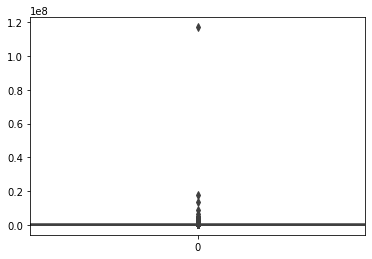

In [342]:
df1.AMT_INCOME_TOTAL.describe()
sns.boxplot(data=df1.AMT_INCOME_TOTAL,width=5)
plt.show()

 <div class="alert alert-block alert-info">
<font size="5">Creating buckets for salary columns </font>
</div> 

In [343]:
df1['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [344]:
# Binning 'AMT_INCOME_RANGE' based on quantiles
df1['AMT_INCOME_TOTAL_RANGE'] = pd.qcut(df1.AMT_INCOME_TOTAL, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VeryLow', 'Low', "Medium", 'High', 'VeryHigh'])
df1['AMT_INCOME_TOTAL_RANGE'].head(11)
df1['AMT_INCOME_TOTAL_RANGE'].value_counts(normalize=True)

Medium      0.346762
Low         0.292962
VeryLow     0.207053
High        0.107583
VeryHigh    0.045641
Name: AMT_INCOME_TOTAL_RANGE, dtype: float64

In [345]:
# Binning 'AMT_CREDIT_RANGE' by creating various ranges
df1['AMT_CREDIT_RANGE'] = pd.qcut(df1.AMT_CREDIT, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VeryLow', 'Low', "Medium", 'High', 'VeryHigh'])
df1['AMT_CREDIT_RANGE'].head(11)

0          Low
1         High
2      VeryLow
3          Low
4          Low
5          Low
6     VeryHigh
7     VeryHigh
8         High
9          Low
10      Medium
Name: AMT_CREDIT_RANGE, dtype: category
Categories (5, object): ['VeryLow' < 'Low' < 'Medium' < 'High' < 'VeryHigh']

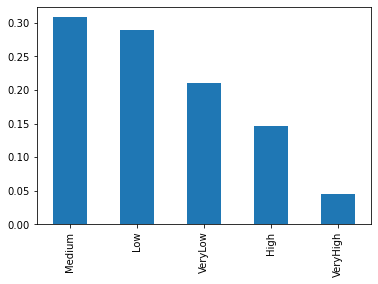

In [346]:
df1['AMT_CREDIT_RANGE'].value_counts(normalize=True).plot.bar()
plt.show()

<div class="alert alert-block alert-success">
<b> Inference - :</b>Medium group people applies for more loan
</div> 

 <div class="alert alert-block alert-info">
<font size="5">Converting birth_days to to their respective age </font>
</div>  

In [347]:
df1['applicant_age']=(df1['DAYS_BIRTH']/365).astype(int)

In [348]:
print(df1.applicant_age.min())
print(df1.applicant_age.max())

20
69


 <div class="alert alert-block alert-info">
<font size="5">Binning the age of applicant </font>
</div>  

In [349]:
# Bucketing 'DAYS_BIRTH'
#df1['applicant_age_bins']=pd.qcut(df1['DAYS_BIRTH'], q=[0,0.25,0.5,0.75,1], labels=['VeryYoung','Young', 'MiddleAge', 'Senior_Citizen'])
# Binning AGE and Creating new column "AGE_GROUP"



In [350]:
df1['applicant_age_bins']= pd.cut(df1['applicant_age'],bins=[15,25,35,45,55,65,75])

df1['applicant_age_bins'].value_counts(normalize=True)

(35, 45]    0.272111
(25, 35]    0.246902
(45, 55]    0.226011
(55, 65]    0.185623
(15, 25]    0.053065
(65, 75]    0.016289
Name: applicant_age_bins, dtype: float64

In [351]:
df1['applicant_age_bins'].head()

0    (15, 25]
1    (35, 45]
2    (45, 55]
3    (45, 55]
4    (45, 55]
Name: applicant_age_bins, dtype: category
Categories (6, interval[int64, right]): [(15, 25] < (25, 35] < (35, 45] < (45, 55] < (55, 65] < (65, 75]]

 <div class="alert alert-block alert-info">
<font size="5"> Analyzing all object variables in application data csv file </font>
</div>  

In [352]:
# Checking all attributes having object as a variable
df1.columns[df1.dtypes=="object"].tolist()

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE']

 <div class="alert alert-block alert-info">
<font size="5"> Checking all object types Variables and their values </font>
</div>    
 

Cash loans         0.904787
Revolving loans    0.095213
Name: NAME_CONTRACT_TYPE, dtype: float64


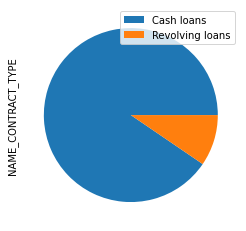

F      0.658344
M      0.341643
NaN    0.000013
Name: CODE_GENDER, dtype: float64


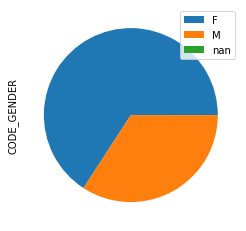

N    0.659892
Y    0.340108
Name: FLAG_OWN_CAR, dtype: float64


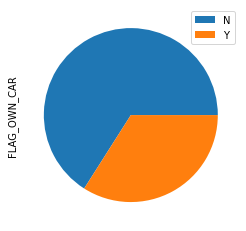

Y    0.693673
N    0.306327
Name: FLAG_OWN_REALTY, dtype: float64


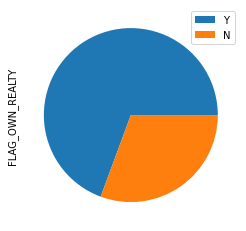

Unaccompanied      0.808186
Family             0.130561
Spouse, partner    0.036974
Children           0.010624
Other_B            0.005756
NaN                0.004201
Other_A            0.002816
Group of people    0.000881
Name: NAME_TYPE_SUITE, dtype: float64


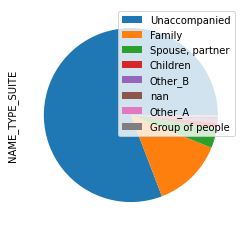

Working                 0.516320
Commercial associate    0.232892
Pensioner               0.180033
State servant           0.070576
Unemployed              0.000072
Student                 0.000059
Businessman             0.000033
Maternity leave         0.000016
Name: NAME_INCOME_TYPE, dtype: float64


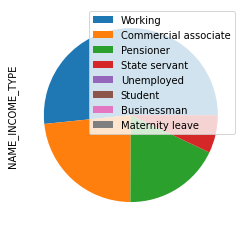

Secondary / secondary special    0.710189
Higher education                 0.243448
Incomplete higher                0.033420
Lower secondary                  0.012409
Academic degree                  0.000533
Name: NAME_EDUCATION_TYPE, dtype: float64


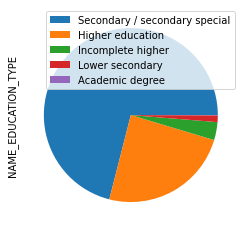

Married                 0.638780
Single / not married    0.147780
Civil marriage          0.096826
Separated               0.064290
Widow                   0.052317
Unknown                 0.000007
Name: NAME_FAMILY_STATUS, dtype: float64


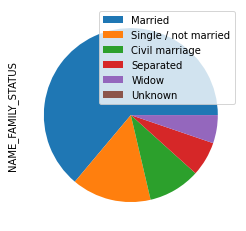

House / apartment      0.887344
With parents           0.048258
Municipal apartment    0.036366
Rented apartment       0.015873
Office apartment       0.008510
Co-op apartment        0.003649
Name: NAME_HOUSING_TYPE, dtype: float64


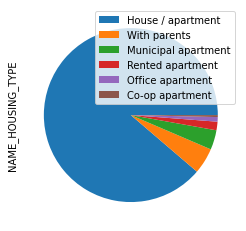

NaN                      0.313455
Laborers                 0.179460
Sales staff              0.104393
Core staff               0.089655
Managers                 0.069497
Drivers                  0.060495
High skill tech staff    0.037007
Accountants              0.031911
Medicine staff           0.027762
Security staff           0.021856
Cooking staff            0.019336
Cleaning staff           0.015131
Private service staff    0.008624
Low-skill Laborers       0.006806
Waiters/barmen staff     0.004384
Secretaries              0.004244
Realty agents            0.002442
HR staff                 0.001831
IT staff                 0.001711
Name: OCCUPATION_TYPE, dtype: float64


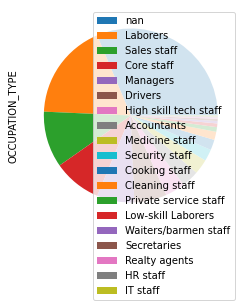

TUESDAY      0.175282
WEDNESDAY    0.168885
MONDAY       0.164918
THURSDAY     0.164518
FRIDAY       0.163695
SATURDAY     0.110084
SUNDAY       0.052619
Name: WEEKDAY_APPR_PROCESS_START, dtype: float64


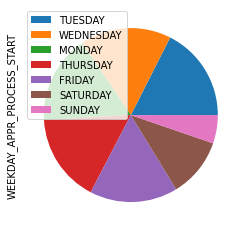

Business Entity Type 3    0.221104
Nan                       0.180072
Self-employed             0.124913
Other                     0.054252
Medicine                  0.036399
Business Entity Type 2    0.034317
Government                0.033833
School                    0.028919
Trade: type 7             0.025466
Kindergarten              0.022373
Construction              0.021856
Business Entity Type 1    0.019459
Transport: type 4         0.017554
Trade: type 3             0.011356
Industry: type 9          0.010952
Industry: type 3          0.010660
Security                  0.010559
Housing                   0.009619
Industry: type 11         0.008793
Military                  0.008566
Bank                      0.008153
Agriculture               0.007980
Police                    0.007613
Transport: type 2         0.007167
Postal                    0.007014
Security Ministries       0.006419
Trade: type 2             0.006179
Restaurant                0.005889
Services            

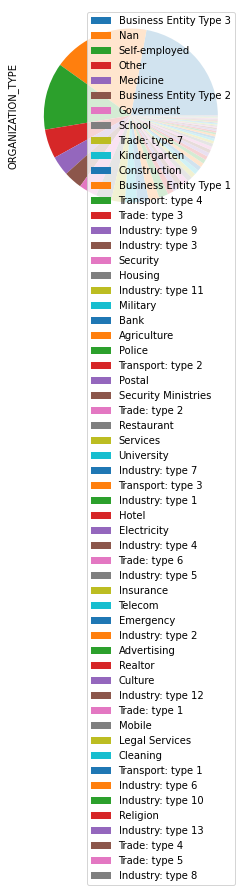

In [353]:
#
obj_cl=df1.columns

for i in obj_cl:
    if df1[i].dtypes=="object":
        print(df1[i].value_counts(normalize=True, dropna= False))
        plt.figure(figsize=[4,4])
        df1[i].value_counts(normalize=True, dropna=False).plot.pie(labeldistance=None)
        plt.legend()
        plt.show()
      

Cash loans         0.904787
Revolving loans    0.095213
Name: NAME_CONTRACT_TYPE, dtype: float64
F      0.658344
M      0.341643
NaN    0.000013
Name: CODE_GENDER, dtype: float64
N    0.659892
Y    0.340108
Name: FLAG_OWN_CAR, dtype: float64
Y    0.693673
N    0.306327
Name: FLAG_OWN_REALTY, dtype: float64
Unaccompanied      0.808186
Family             0.130561
Spouse, partner    0.036974
Children           0.010624
Other_B            0.005756
NaN                0.004201
Other_A            0.002816
Group of people    0.000881
Name: NAME_TYPE_SUITE, dtype: float64
Working                 0.516320
Commercial associate    0.232892
Pensioner               0.180033
State servant           0.070576
Unemployed              0.000072
Student                 0.000059
Businessman             0.000033
Maternity leave         0.000016
Name: NAME_INCOME_TYPE, dtype: float64
Secondary / secondary special    0.710189
Higher education                 0.243448
Incomplete higher                0.033420
L

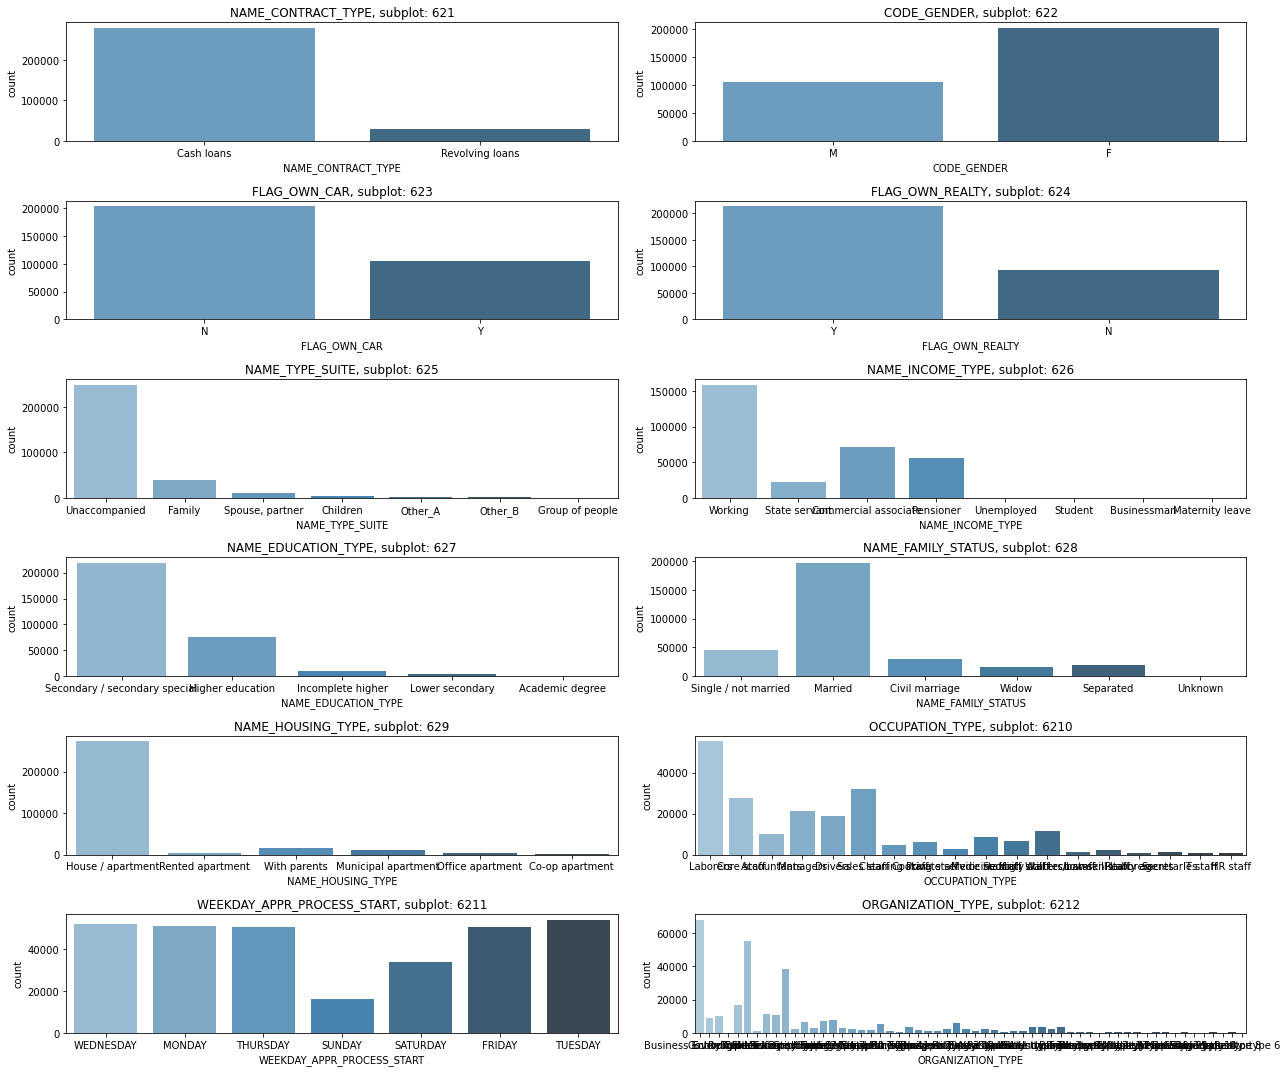

In [354]:
row = 6  # number of rows
col = 2  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(18,15))

for i in obj_cl:
    if df1[i].dtypes=="object":

        plt.subplot(row, col, c)
        plt.title (f"{i}, subplot: {row}{col}{c}")
        plt.xlabel(i)
        print(df1[i].value_counts(normalize=True, dropna=False))
        sns.countplot(df1[i],palette="Blues_d")
        c = c + 1

fig.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    . Female-65.9%>Male-34.1% in terms of taking loans 
    
    . 80% people are unaccompained while taking loan
    
    . 65% applicant dont own cars
    
    . 69% applicants own living quarters
    
    . Cash loans offered are more than revolving loans, at 90.4%
    
    . 81% applicants came accompanied for loan application
    
    . While most applicants are working class, 18% are pensioners
    
    . 71% of applicant is have secondary education
    
    . 63.8%% are married
    
    . 31.3% have not mentioned their OCCUPATION_TYPE 
    
</div>




   
  
    



    

In [355]:
df1['AMT_ANNUITY'].describe()

count    307511.000000
mean      27108.487841
std       14493.461065
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

In [356]:
for i in obj_cl:
    if df1[i].dtypes=="object":

        print(df1[i].value_counts(normalize=True)*100)
      

Cash loans         90.478715
Revolving loans     9.521285
Name: NAME_CONTRACT_TYPE, dtype: float64
F    65.835249
M    34.164751
Name: CODE_GENDER, dtype: float64
N    65.989184
Y    34.010816
Name: FLAG_OWN_CAR, dtype: float64
Y    69.367275
N    30.632725
Name: FLAG_OWN_REALTY, dtype: float64
Unaccompanied      81.159562
Family             13.111205
Spouse, partner     3.713029
Children            1.066884
Other_B             0.578018
Other_A             0.282804
Group of people     0.088499
Name: NAME_TYPE_SUITE, dtype: float64
Working                 51.631974
Commercial associate    23.289248
Pensioner               18.003258
State servant            7.057634
Unemployed               0.007154
Student                  0.005853
Businessman              0.003252
Maternity leave          0.001626
Name: NAME_INCOME_TYPE, dtype: float64
Secondary / secondary special    71.018923
Higher education                 24.344820
Incomplete higher                 3.341994
Lower secondary        

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     1.  66.045853% Females have taken  loans in comparison to 33.954147 % male.
    
    2.  More than half, 66.281113 applicant dont own cars
    
    3.  Married people are more applying for loan compared to other family status by 63%
    
    4.  More than half  applicants own living quarters
    
    5.  Majority of applicant are  working class
    
    6.  26% labourers is highest in OCCUPATION_TYPE
    
    7.  Cash loans are  90.56017% more than revolving loans
    
    8.  71% have secondary education
    
    9.  31% have not mentioned their occupation type
    
    10. 81.108792% Unaccompanied was accompained while applying for loan
    
</div>




   
  
    

 <div class="alert alert-block alert-info">
<font size="5"> Plotting for int and float numerical variable in application data </font>
</div>    
 


ValueError: num must be 1 <= num <= 15, not 16

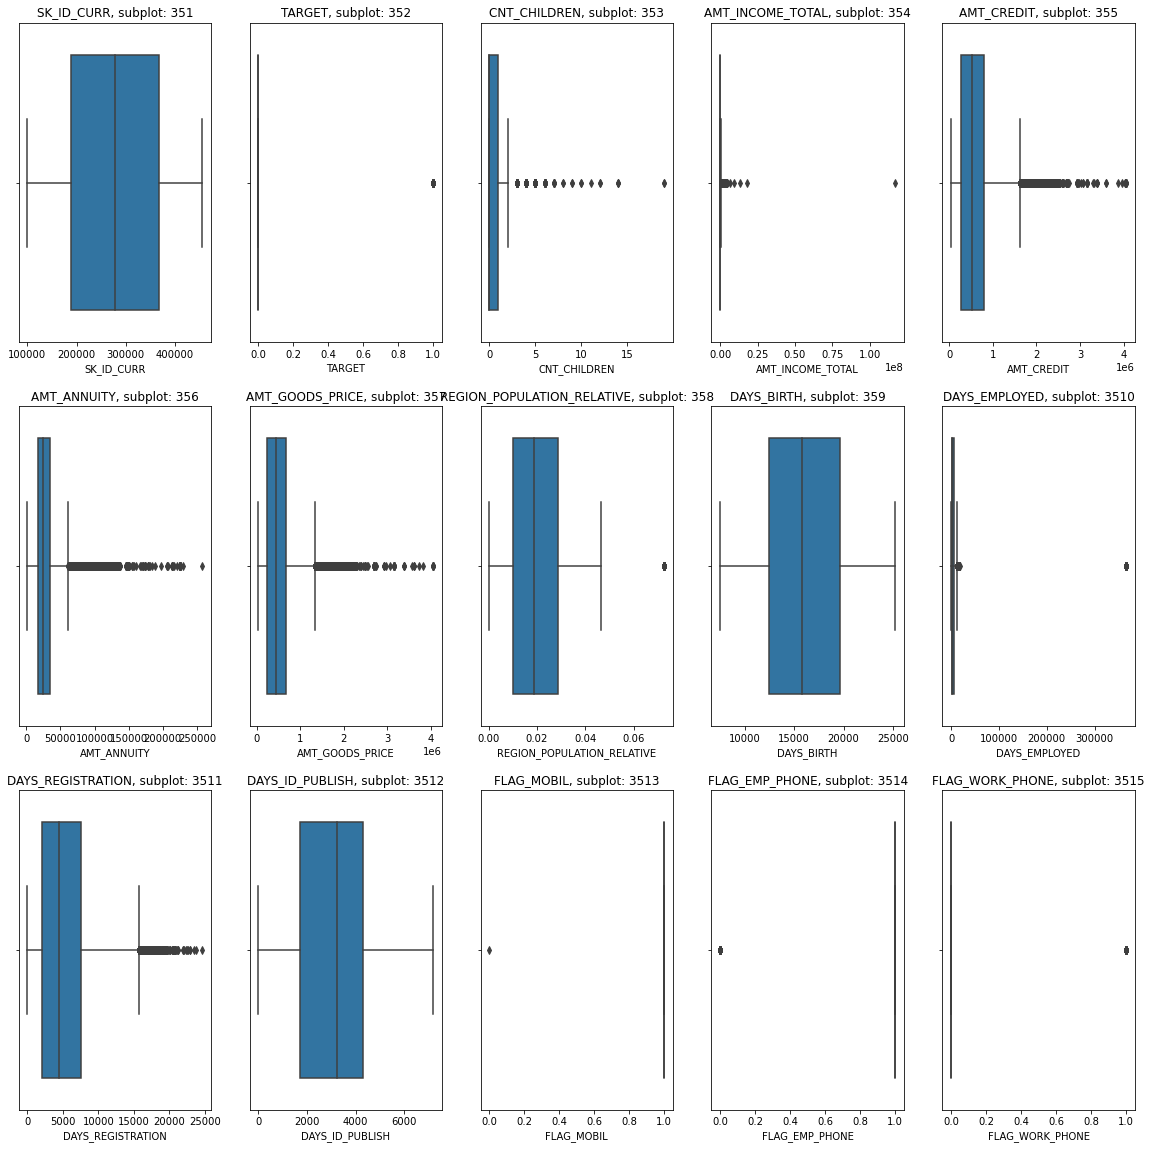

In [357]:
column = 5    #  columns
c = 1        #  counter
row = 3      #  rows

fig = plt.figure(figsize=(20,20))

for i in df1.columns:
    if df1[i].dtypes=="int64" or df1[i].dtypes=="int32"  or df1[i].dtypes=="float":
        plt.subplot(row, column, c)
        plt.title (f"{i}, subplot: {row}{column}{c}")
        plt.xlabel(i)
        sns.boxplot(df1[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    Handling - Filled null value to all rows where loan applied date was greater than their birth age
</div>


<div class="alert alert-block alert-success">
<b>Point to Note:</b>
    AMT_REQ_CREDIT_BUREAU signifies which companies  may  trigger firms to check applicant's credit score.
    
    i.e
    
    . Places applicant looked for loan parallely. 
    
    . Number of applications or loans were applied for and/or taken in last one yaer
      This is an important indicator
     
      NaN can either signify whetjer applicant got loans or connection between our Server and firm failed
</div>

In [ ]:
"""for i in df1.columns:
if i.startswith("AMT_REQ"):
df1[i].fillna(value=(df1[i].mode()[0]), inplace=True)"""

# Handling nan values in columns whose missing % is less than 50%

In [ ]:
#filling null with mode value
df1['AMT_REQ_CREDIT_BUREAU_YEAR']=df1['AMT_REQ_CREDIT_BUREAU_YEAR'].fillna(df1['AMT_REQ_CREDIT_BUREAU_YEAR'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['AMT_REQ_CREDIT_BUREAU_HOUR']=df1['AMT_REQ_CREDIT_BUREAU_HOUR'].fillna(df1['AMT_REQ_CREDIT_BUREAU_HOUR'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['AMT_REQ_CREDIT_BUREAU_DAY']=df1['AMT_REQ_CREDIT_BUREAU_DAY'].fillna(df1['AMT_REQ_CREDIT_BUREAU_DAY'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['AMT_REQ_CREDIT_BUREAU_MON']=df1['AMT_REQ_CREDIT_BUREAU_MON'].fillna(df1['AMT_REQ_CREDIT_BUREAU_MON'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['AMT_REQ_CREDIT_BUREAU_QRT']=df1['AMT_REQ_CREDIT_BUREAU_QRT'].fillna(df1['AMT_REQ_CREDIT_BUREAU_QRT'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['AMT_REQ_CREDIT_BUREAU_WEEK']=df1['AMT_REQ_CREDIT_BUREAU_WEEK'].fillna(df1['AMT_REQ_CREDIT_BUREAU_WEEK'].mode(),inplace=False)# mode because its an categorical type and mean would have create data imbalance
df1['OCCUPATION_TYPE']=df1['OCCUPATION_TYPE'].fillna(df1['OCCUPATION_TYPE'].mode(),inplace=False)
df1['NAME_TYPE_SUITE']=df1['NAME_TYPE_SUITE'].fillna(df1['NAME_TYPE_SUITE'].mode(),inplace=False)
#filling null with mode value


 <div class="alert alert-block alert-info">
<font size="5"> Handling outlier for, which we infered from above graph </font>
</div>    
 
    AMT_GOODS_PRICE
    AMT_CREDIT
    CNT_CHILDREN
    days_employed
    DAYS_REGISTRATION
    AMT_ANNUITY
    AMT_INCOME_TOTAL
    
    

 <div class="alert alert-block alert-info">
<font size="5"> Handling AMT_GOODS_PRICE Outlier </font>
</div>

In [ ]:
df1.AMT_GOODS_PRICE.describe()

In [ ]:
df1.AMT_GOODS_PRICE.median()

In [ ]:
df1.AMT_GOODS_PRICE.quantile([.5,.7,.80,.87,.90,.92,.95,.99,1])#definately theres an outlier

In [ ]:
# Handling by adding medain as it is amount, and mean would create imbalance in dataset
df1.loc[df1.AMT_GOODS_PRICE>df1.AMT_GOODS_PRICE.quantile(.95),'AMT_GOODS_PRICE'] = df1['AMT_GOODS_PRICE'].median()

In [ ]:
sns.boxplot(df1['AMT_GOODS_PRICE'])
plt.show()

 <div class="alert alert-block alert-info">
<font size="5"> Handling AMT_CREDIT Outlier </font>
</div>

In [ ]:
df1.AMT_CREDIT.describe()

In [ ]:
df1.AMT_CREDIT.median()

In [ ]:
df1.AMT_CREDIT.quantile([.5,.7,.80,.87,.90,.92,.95,.99,1])#definately theres an outlier

In [ ]:
# Handling by adding medain as it is amount, and mean would create imbalance in dataset
df1.loc[df1.AMT_CREDIT>df1.AMT_CREDIT.quantile(.95),'AMT_CREDIT'] = df1['AMT_CREDIT'].median()

In [ ]:
sns.boxplot(df1['AMT_CREDIT'])
plt.show()

 <div class="alert alert-block alert-info">
<font size="5">Handling CNT_CHILDREN Outlier </font>
</div>

In [ ]:
df1.CNT_CHILDREN.describe()

In [ ]:
df1.CNT_CHILDREN.mode()

In [ ]:
df1.CNT_CHILDREN.quantile([.5,.7,.80,.87,.90,.92,.95,.99,1])#definately theres an outlier

In [ ]:
# Handling by adding modeas it is number of children, and mean would create imbalance in dataset
df1.loc[df1.CNT_CHILDREN>df1.CNT_CHILDREN.quantile(.95),'CNT_CHILDREN'] = df1['CNT_CHILDREN'].mode()

In [ ]:
sns.boxplot(df1['CNT_CHILDREN'])
plt.show()

 <div class="alert alert-block alert-info">
<font size="5">Handling DAYS_REGISTRATION Outlier </font>
</div> 

In [ ]:
df1.DAYS_REGISTRATION.quantile([.5,.7,.80,.87,.90,.95,.99,1])#definately theres an outlier

In [ ]:
sns.boxplot(df1["DAYS_REGISTRATION"] )
plt.show()
df1["DAYS_REGISTRATION"].describe()
#lot of outliers


<div class="alert alert-block alert-success">
<b>Inference:</b> 
    In the following observation, the value which is greater that 24000  is surely an outlier
</div>



In [ ]:
#handling
df1.loc[df1.DAYS_REGISTRATION>df1.DAYS_REGISTRATION.quantile(.99),'DAYS_REGISTRATION'] = df1['DAYS_REGISTRATION'].mode()

 <div class="alert alert-block alert-info">
<font size="5">Handling AMT_ANNUITY Outlier </font>
</div> 

In [ ]:
df1.AMT_ANNUITY.quantile([.1,.5,.7,.8,.9,.92,.95,.99,1])

In [ ]:
sns.boxplot(df1["AMT_ANNUITY"] )
plt.show()
df1["AMT_ANNUITY"].describe()
#lot of outliers

In [ ]:
#handling
df1.loc[df1['AMT_ANNUITY']>df1.AMT_ANNUITY.quantile(.95),'AMT_ANNUITY'] = df1['AMT_ANNUITY'].median()

In [ ]:
"""sns.boxplot(df1["AMT_ANNUITY"] )
plt.show()
df1["AMT_ANNUITY"].describe()
#lot of outliers"""  #remove after checking

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    In the following observation, the value which is greater than 258000 which is surely an outlier.
</div>


 <div class="alert alert-block alert-info">
<font size="5">Handling AMT_INCOME_TOTAL Outlier</font>
</div>  

In [ ]:
sns.boxplot(df1.AMT_INCOME_TOTAL )
plt.show()
df1.AMT_INCOME_TOTAL.describe()
#lot of outliers

In [ ]:
df1.AMT_INCOME_TOTAL.quantile([.1,.5,.7,.8,.9,.92,.95,.99,1])

In [ ]:
income_outlier= (np.where(df1.AMT_INCOME_TOTAL>472500))
df1.drop(df1[df1['AMT_INCOME_TOTAL']>df1.AMT_INCOME_TOTAL.quantile(.95)].index,inplace=True)

 <div class="alert alert-block alert-info">
<font size="5">Removed outlier value 117000000, by deleting the row completely, as data is flawed</font>
</div>   

In [ ]:
df1.AMT_INCOME_TOTAL.quantile([.1,.5,.7,.8,.9,.92,.95,.99,1])

 <div class="alert alert-block alert-info">
<font size="5">Checking outlier after removal of all outlier</font>
</div>    

In [ ]:

# INT Data - Histogram - Analysis by plotting Histograms

row = 3  # number of rows
column = 5  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,20))

for i in df1.columns:
    if df1[i].dtypes=="int64" or df1[i].dtypes=="int32"  or df1[i].dtypes=="float64"  or df1[i].dtypes=="float32":
        plt.subplot(row, column, c)
        plt.title (f"{i}, subplot: {row}{column}{c}")
        plt.xlabel(i)
        sns.boxplot(df1[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()

 <div class="alert alert-block alert-info">
<font size="5">Sanity check- All applicant loan applied days before employment should be less than 69 years</font>
</div>     

In [ ]:
print(np.where(df1.DAYS_EMPLOYED>(69*365)) and (np.where(df1.applicant_age<69) ))

In [ ]:
wr=(df1['DAYS_EMPLOYED']>(69*365)) & (df1['applicant_age']<69)
wr.sum()

In [ ]:
(df1.DAYS_EMPLOYED).describe()

In [ ]:
sns.boxplot(df1['DAYS_EMPLOYED'],palette="Set2")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     Checking with 69 because all applicant maximum age is 69. Since no one can apply for loan before they are born, so we could drop these data or fill with mode value, as it makes no sense.
</div>



 <div class="alert alert-block alert-info">
<font size="5">Handling all row where days_employed>applicants age</font>
</div>      

In [ ]:
df1.DAYS_EMPLOYED.quantile([.5,.7,.80,.81,.82,.99,.95,1])#definately theres an outlier

In [ ]:
#handling
df1.loc[df1.DAYS_EMPLOYED>df1.DAYS_EMPLOYED.quantile(.81),'DAYS_EMPLOYED'] = df1['DAYS_EMPLOYED'].mode()
      

 <div class="alert alert-block alert-info">
<font size="5"> Checking data distributions</font>
</div>     

In [ ]:
df1["OCCUPATION_TYPE"].value_counts(normalize=True).plot.bar()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
   Labourers,  drivers sales staff, core staffoccupies
   50% of defaulters. Among them Laborers applies more loan, makes sense also. 
</div>
    




In [358]:
df1["OCCUPATION_TYPE"].value_counts(normalize=True)*100

Laborers                 26.139636
Sales staff              15.205570
Core staff               13.058924
Managers                 10.122679
Drivers                   8.811576
High skill tech staff     5.390299
Accountants               4.648067
Medicine staff            4.043672
Security staff            3.183498
Cooking staff             2.816408
Cleaning staff            2.203960
Private service staff     1.256158
Low-skill Laborers        0.991379
Waiters/barmen staff      0.638499
Secretaries               0.618132
Realty agents             0.355722
HR staff                  0.266673
IT staff                  0.249147
Name: OCCUPATION_TYPE, dtype: float64

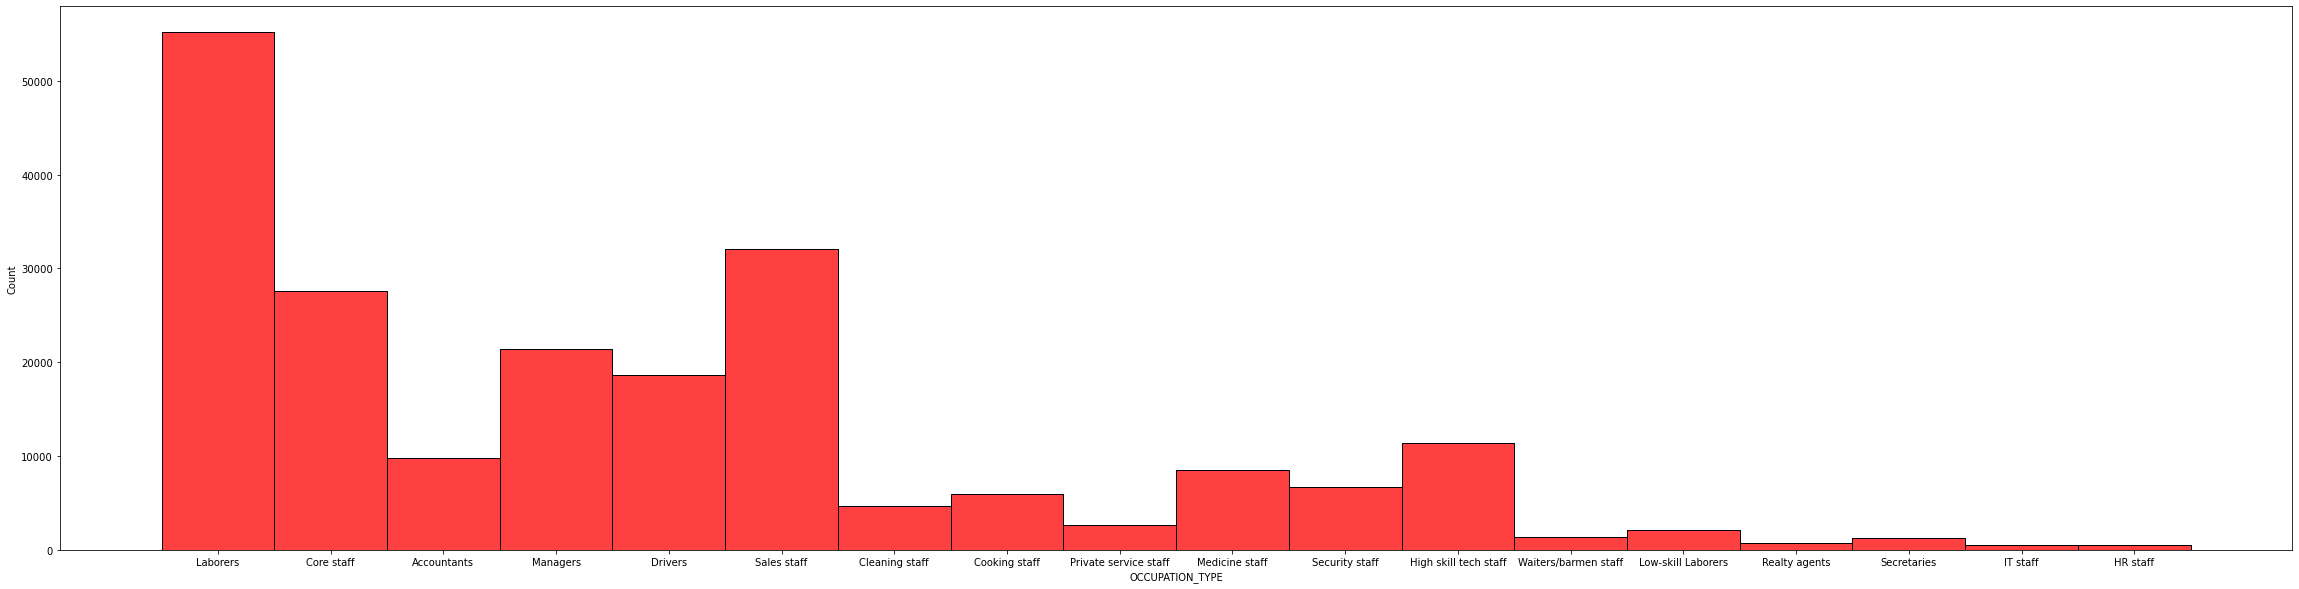

In [359]:
# Distribution of 'OCCUPATION_TYPE'
plt.figure(figsize=(40,10))
dst = df1["OCCUPATION_TYPE"].value_counts()
sns.histplot(df1.OCCUPATION_TYPE,bins='auto',color='red')
plt.show()


<div class="alert alert-block alert-success">
<b>Inference:</b> 
     It seems people with occupation type laborers applies more number of loans than It staff and Hr
</div>


 <div class="alert alert-block alert-info">
<font size="5">  Checking NAME_CONTRACT_TYPE</font>
</div>     

In [360]:
df1["NAME_CONTRACT_TYPE"].value_counts(normalize=True)

Cash loans         0.904787
Revolving loans    0.095213
Name: NAME_CONTRACT_TYPE, dtype: float64

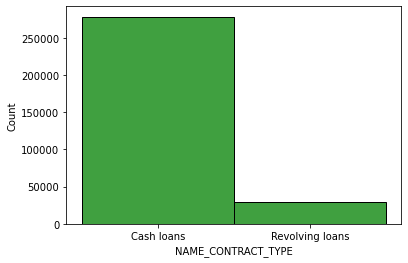

In [361]:
# plt.figure(figsize=(3,3))
loandst = df1["NAME_CONTRACT_TYPE"].value_counts()
sns.histplot(df1["NAME_CONTRACT_TYPE"],bins='auto',color='green',cumulative=False)
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     Cash Loans are large part of the company's portfolio.
</div>



In [362]:
loandst

Cash loans         278232
Revolving loans     29279
Name: NAME_CONTRACT_TYPE, dtype: int64

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     Majority of people usually go for Cash Loans
</div>
 


<div class="alert alert-block alert-success">
<b>Inference:</b> 
    People are taking more cash loans than revolving type
</div>

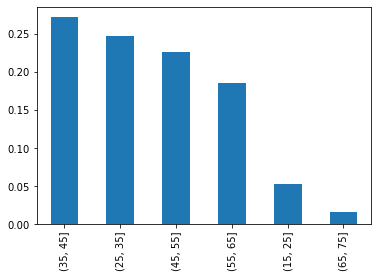

In [363]:

df1['applicant_age_bins'].value_counts(normalize=True).plot.bar()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     - 35-45 Age group applies more loans. They are major consumer of goods
</div>
 


 <div class="alert alert-block alert-info">
<font size="5">  Creating buckets for salary columns</font>
</div>    

In [364]:
df1['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [365]:
# Binning 'AMT_INCOME_RANGE' based on quantiles
df1['AMT_INCOME_TOTAL_RANGE'] = pd.qcut(df1.AMT_INCOME_TOTAL, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VeryLow', 'Low', "Medium", 'High', 'VeryHigh'])
df1['AMT_INCOME_TOTAL_RANGE'].head(11)
df1['AMT_INCOME_TOTAL_RANGE'].value_counts(normalize=True)

Medium      0.346762
Low         0.292962
VeryLow     0.207053
High        0.107583
VeryHigh    0.045641
Name: AMT_INCOME_TOTAL_RANGE, dtype: float64

In [366]:
# Binning 'AMT_CREDIT_RANGE' by creating various ranges
df1['AMT_CREDIT_RANGE'] = pd.qcut(df1.AMT_CREDIT, q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VeryLow', 'Low', "Medium", 'High', 'VeryHigh'])
df1['AMT_CREDIT_RANGE'].head(11)

0          Low
1         High
2      VeryLow
3          Low
4          Low
5          Low
6     VeryHigh
7     VeryHigh
8         High
9          Low
10      Medium
Name: AMT_CREDIT_RANGE, dtype: category
Categories (5, object): ['VeryLow' < 'Low' < 'Medium' < 'High' < 'VeryHigh']

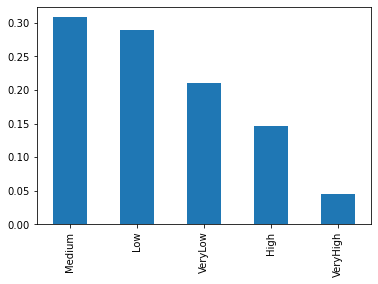

In [367]:
df1['AMT_CREDIT_RANGE'].value_counts(normalize=True).plot.bar()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     Medium group people applies for more loan
</div>
 

 <div class="alert alert-block alert-info">
<font size="5">  Checking TARGET</font>
</div>    

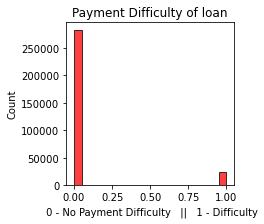

In [368]:
plt.figure(figsize=(3,3))
dst = df1["TARGET"].value_counts()
plt.title("Payment Difficulty of loan")
plt.xlabel(" 0 - No Payment Difficulty   ||   1 - Difficulty")
sns.histplot(df1["TARGET"],bins='auto',color='red')
plt.show()

In [369]:
#checking ratio for target variable between 0 and 1
df1[df1.TARGET==0].shape[0]/df1[df1.TARGET==1].shape[0]

11.387150050352467

<div class="alert alert-block alert-success">
<b>Inference:</b> 
     For every 11 applicant there 1 applicant with loan repayment difficulty
</div>
 

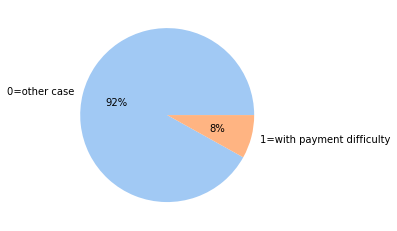

In [370]:
tardst = df1["TARGET"].value_counts()
label = ['0=other case','1=with payment difficulty']
colors = sns.color_palette('pastel')[0:5]
plt.pie(tardst,labels=label, colors = colors, autopct='%.0f%%')
plt.show()


<div class="alert alert-block alert-success">
<b>Inference:</b> 
     High imbalance in data of target column, will have to divide dataset into 2 parts
</div>


 <div class="alert alert-block alert-info">
<font size="5">Making two sets of data: data1 having target- 0; data2 having target- 1 customer</font>
</div>     

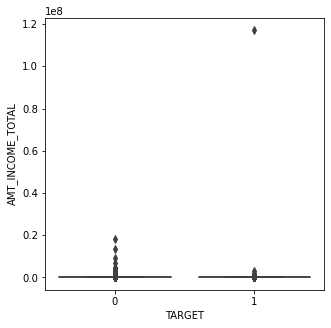

In [371]:
plt.figure(figsize=[5,5])
sns.boxplot(data=df1,x='TARGET',y='AMT_INCOME_TOTAL' )
plt.show()

In [372]:
data1 = df1.loc[df1['TARGET'] == 0]


In [373]:
data1.shape

(282686, 77)

In [374]:
data2 = df1.loc[df1['TARGET'] == 1]

In [375]:
data2.shape

(24825, 77)

In [376]:
gender = data1["CODE_GENDER"].value_counts(normalize=True)*100
gender

F    66.60417
M    33.39583
Name: CODE_GENDER, dtype: float64

 <div class="alert alert-block alert-info">
<font size="5">Univariate Analysis</font>
</div>     

 <div class="alert alert-block alert-info">
<font size="5">Analysis of Cateogarical Unordered Variable</font>
</div> 

    ["CODE_GENDER"]
    
    ["NAME_INCOME_TYPE"]
    
    ["NAME_FAMILY_STATUS"]
    
    ["NAME_CONTRACT_TYPE"]
    
    ["NAME_CONTRACT_TYPE"]
    
    ['ORGANIZATION_TYPE']

 <div class="alert alert-block alert-info">
<font size="5">  Analysis for data1( Applicant who have no repayment difficulty)</font>
</div>   

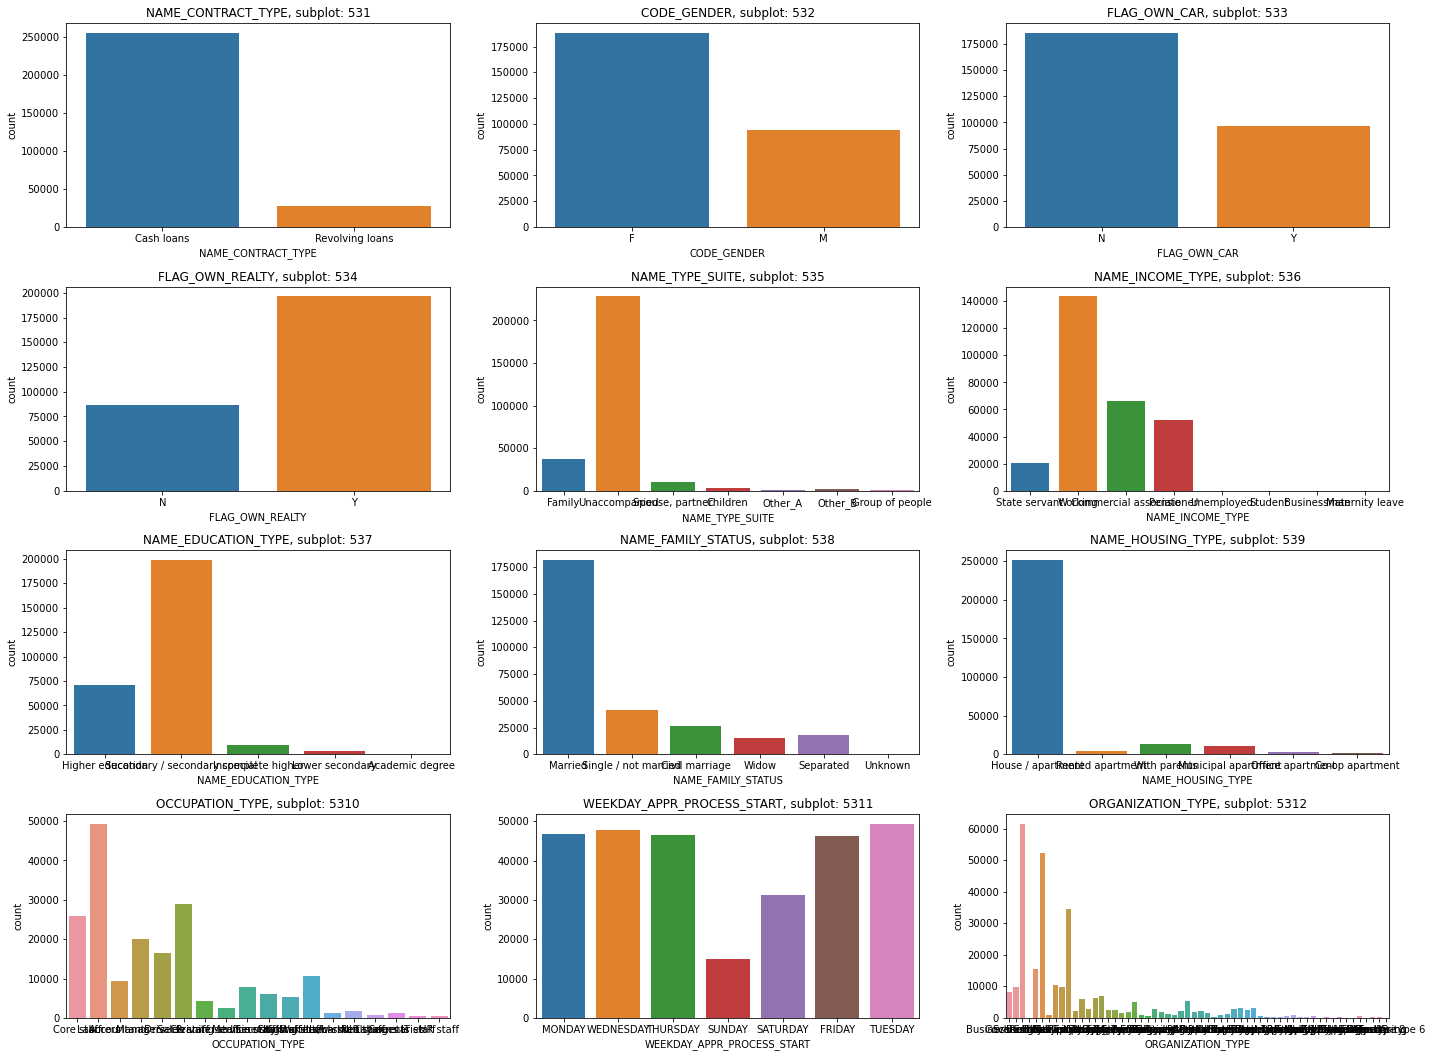

In [377]:

# INT Data - Histogram - Analysis by plotting Histograms

a = 5  # number of rows
b = 3  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,18))

for i in data1.columns:
    if data1[i].dtypes=="object" :
        plt.subplot(a, b, c)
        plt.title('{}, subplot: {}{}{}'.format(i, a, b, c))
        plt.xlabel(i)
        #data1[i].plot.hist()
        sns.countplot(data1[i])
        c = c + 1

fig.tight_layout()
plt.show()

In [378]:
for i in data1.columns:
    if data1[i].dtypes=="object" :
        print(data1[i].value_counts(normalize=True)*100)



Cash loans         90.209986
Revolving loans     9.790014
Name: NAME_CONTRACT_TYPE, dtype: float64
F    66.60417
M    33.39583
Name: CODE_GENDER, dtype: float64
N    65.682418
Y    34.317582
Name: FLAG_OWN_CAR, dtype: float64
Y    69.451264
N    30.548736
Name: FLAG_OWN_REALTY, dtype: float64
Unaccompanied      81.072180
Family             13.195293
Spouse, partner     3.721613
Children            1.075093
Other_B             0.567035
Other_A             0.280675
Group of people     0.088111
Name: NAME_TYPE_SUITE, dtype: float64
Working                 50.780725
Commercial associate    23.438373
Pensioner               18.529393
State servant            7.235590
Student                  0.006367
Unemployed               0.004952
Businessman              0.003537
Maternity leave          0.001061
Name: NAME_INCOME_TYPE, dtype: float64
Secondary / secondary special    70.349080
Higher education                 25.064559
Incomplete higher                 3.327013
Lower secondary          


<div class="alert alert-block alert-success">
<b># Inference for people having no repayment difficulty:</b> 
        TYPE- NAME CONTRACT
    
        Cash Loans account for a significant portion of the company's portfolio.
        0 - 85% for the target


        . NAME TYPE SUIT - Target 0: 80-90 percent


        NAME FAMILY STATUS - Married applicants have defaulted on payments in over 60% of cases.
        In the case of Target 0, NAME INCOME TYPE is 50% effective.


        . NAME EDUCATION TYPE - Applicants with a secondary education applied for 
        loans more than others in both Target 0 and Target 1.


        . Applicants with secondary income account for 90% of defaulted payments.
          More research is required.



         . -85-90 percent in Target 0 for NAME HOSUING TYPE


         . OCCUPATION TYPE - 50% of defaulters are labourers, salespeople, core employees, and drivers.
            Also, the biggest percentage of applicants are labourers.


       
</div>
 

   
  
    
    
    

 <div class="alert alert-block alert-info">
<font size="5">  Analysis for data2( Applicant who have  repayment difficulty)</font>
</div>    

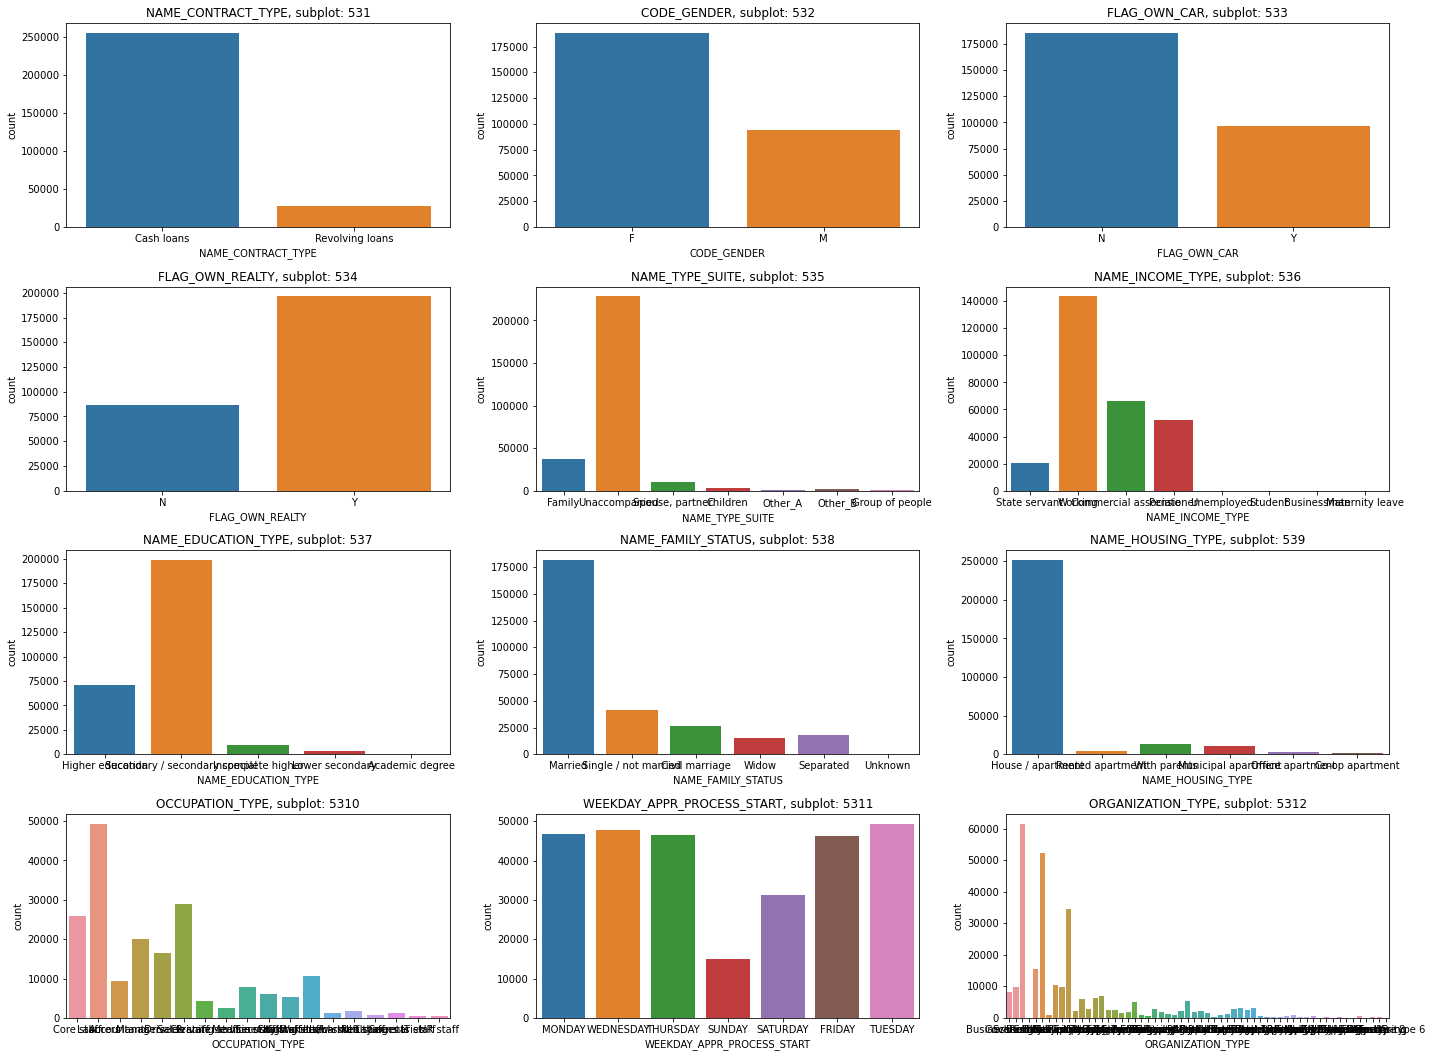

In [379]:
row = 5  # number of rows
col = 3  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,18))

for i in data2.columns:
    if data2[i].dtypes=="object" :
        plt.subplot(a, b, c)
        plt.title (f"{i}, subplot: {row}{col}{c}")
        plt.xlabel(i)
        #data1[i].plot.hist()
        sns.countplot(data1[i])
        c = c + 1

fig.tight_layout()
plt.show()

In [380]:
for i in data1.columns:
    if data2[i].dtypes=="object" :
        print(data2[i].value_counts(normalize=True)*100)



Cash loans         93.538771
Revolving loans     6.461229
Name: NAME_CONTRACT_TYPE, dtype: float64
F    57.079557
M    42.920443
Name: CODE_GENDER, dtype: float64
N    69.482377
Y    30.517623
Name: FLAG_OWN_CAR, dtype: float64
Y    68.410876
N    31.589124
Name: FLAG_OWN_REALTY, dtype: float64
Unaccompanied      82.153100
Family             12.155120
Spouse, partner     3.615431
Children            0.973541
Other_B             0.702888
Other_A             0.307009
Group of people     0.092911
Name: NAME_TYPE_SUITE, dtype: float64
Working                 61.325277
Commercial associate    21.591138
Pensioner               12.012085
State servant            5.031219
Unemployed               0.032226
Maternity leave          0.008056
Name: NAME_INCOME_TYPE, dtype: float64
Secondary / secondary special    78.646526
Higher education                 16.149043
Incomplete higher                 3.512588
Lower secondary                   1.679758
Academic degree                   0.012085
Name:

# Inference for people having  repayment difficulty target-1

<div class="alert alert-block alert-success">
<b>Inference:</b>
    
    Seems people having working type of income has more payment difficulty among all payment difficulty.
    
     . Single/divorced people are most defaulters
    
     . NAME CONTRACT TYPE- Cash Loans make up a significant portion of the firm's portfolio.
        95 percent for Target 1.
        Target 1 is applying for a loan unaccompanied. 
    
    . NAME TYPE SUIT - Target 1 is applying for a loan unaccompanied.
       This indicates that this is not a parameter that has the ability to change payment default.


    . NAME INCOME TYPE - In the instance of Target 1, 
       working income categories account for 60% of the total.


    . NAME EDUCATION TYPE - Applicants with a secondary education applied for 
       loans more frequently than others in Target 1.
        Applicants with secondary income account for 90% of defaulted payments.
        More research is required.


    . NAME HOSUING TYPE – Applicants in Target 1 are staying at a "House/apartment."
      This indicates that this is not a parameter that has the ability to change payment default. 
    
    . ORGANIZATION TYPE - SELF-EMPLOYED BUSINESS and ENTITY TYPE 3 AND ADD UP TO 40% DEFAULTERS
           This group also has the largest percentage of loan takers. 

</div>

     

 <div class="alert alert-block alert-info">
<font size="5">  Univariate Analysis of Continous variable</font>
</div>    

ValueError: num must be 1 <= num <= 15, not 16

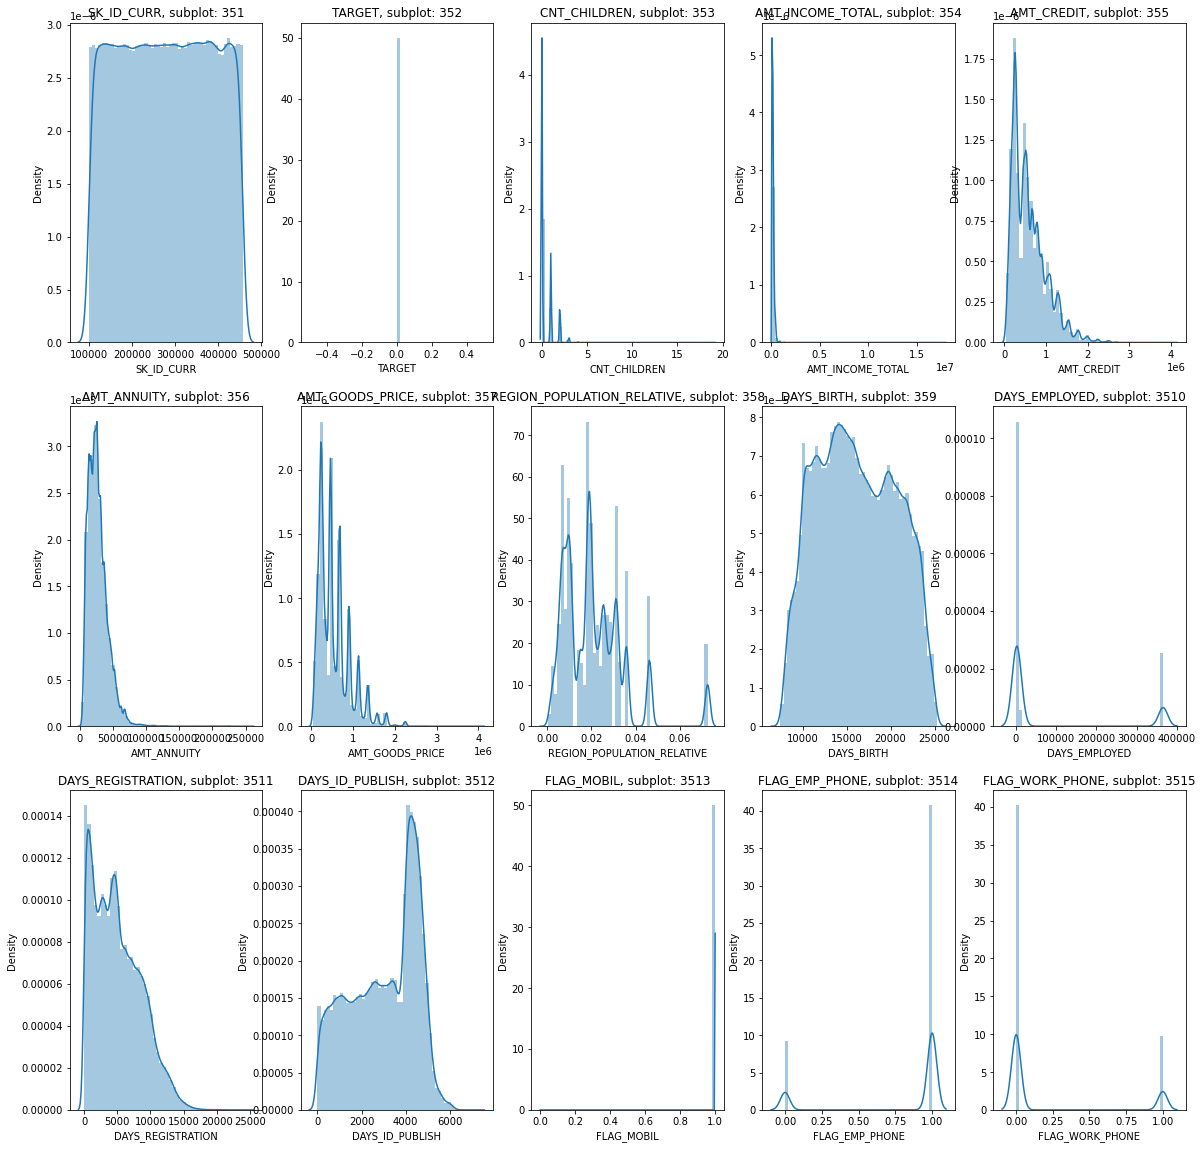

In [381]:
#distplot
a = 3  # number of rows
b = 5  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,20))

for i in data1.columns:
    if data1[i].dtypes=="int64" or data1[i].dtypes=="int32"  or data1[i].dtypes=="float":
        plt.subplot(a, b, c)
        plt.title (f"{i}, subplot: {a}{b}{c}")
        plt.xlabel(i)
        sns.distplot(data1[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()


In [ ]:

# INT Data - Histogram - Analysis by plotting Histograms

a = 3  # number of rows
b = 5  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,20))

for i in data1.columns:
    if data1[i].dtypes=="int64" or data1[i].dtypes=="int32"  or data1[i].dtypes=="float":
        plt.subplot(a, b, c)
        plt.title (f"{i}, subplot: {a}{b}{c}")
        plt.xlabel(i)
        sns.boxplot(data1[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()

##### **Inference**
<div class="alert alert-block alert-success">
    
    
    

    
    . EXT_SOURCE_2 is clearing showing that TARGET 0 has higher densiy of higher scores
    
    . AGE_IN_YEARS Density of 30 years in Target 1 larger, indicating younger are defaulting more
    
    
    . YEARS_EMPLOYED has large no of rows of incorrect data and hence the data representation is incorrect
     observed in social surroundign is higher.
    
 
</div>



    
    

 <div class="alert alert-block alert-info">
<font size="5"> Analysis for data2( Applicant who have no repayment difficulty)</font>
</div>     

In [ ]:

# INT Data - Histogram - Analysis by plotting Histograms

row = 3  # number of rows
column = 5  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,20))

for i in data2.columns:
    if data2[i].dtypes=="int64" or data1[i].dtypes=="int32"  or data1[i].dtypes=="float":
        plt.subplot(row, column, c)
        plt.title (f"{i}, subplot: {row}{column}{c}")
        plt.xlabel(i)
        sns.distplot(data2[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()


In [ ]:

# INT Data - Histogram - Analysis by plotting Histograms

row = 3  # number of rows
column = 5  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,20))

for i in data2.columns:
    if data2[i].dtypes=="int64" or data1[i].dtypes=="int32"  or data1[i].dtypes=="float":
        plt.subplot(row, column, c)
        plt.title (f"{i}, subplot: {row}{column}{c}")
        plt.xlabel(i)
        sns.boxplot(df1[i])
        
        #data1[i].plot.hist()
        c = c + 1

fig.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    .AMT_CREDIT - Appears lower for Target 1, which is a good sign as lesser default loss to the company.
    
    . DAYS_LAST_PHONE_CHANGE- More people from the Target 1 have changed their phone earlier than Target 1. Indicating intention issues in repaying loan
    
    . AGE_IN_YEARS Density of 30 years in Target 1 larger, indicating younger are defaulting more
    
    . YEARS_EMPLOYED has large no of rows of incorrect data and hence the data representation is incorrect
    
    
    . AMT_REQ_CREDIT_BUREAU_YEAR, month, week, hour - has lesser Target 1 at 0 hits. This could indicate they are looking getting loans from various financial companies
    
    . Lesser no of Target 1 OWN cars
</div>

  
    
    

 <div class="alert alert-block alert-info">
<font size="5">   Bivariate analysis</font>
</div>   

In [ ]:
## AMT_INCOME_TOTAL_RANGE vs AMT_CREDIT for both data frames

plt.figure(figsize = (18,5))
plt.subplot(1,2,1)
plt.title("Income range and Amt Credited for Target 0")
sns.boxplot(x = 'AMT_INCOME_TOTAL_RANGE', y = 'AMT_CREDIT', data =data1, showfliers=False, palette="Paired")

plt.subplot(1,2,2)
plt.title("Income Group and Amt Credited for Target 1")
sns.boxplot(x = 'AMT_INCOME_TOTAL_RANGE', y = 'AMT_CREDIT', data = data2, showfliers=False, palette="Paired")
plt.show()

In [ ]:
#Checking the same columns to see the affect of Very High Income group
plt.figure(figsize = (20,4))
plt.subplot(1,2,1)
plt.title("Income_range and Payment Diffculty")
sns.countplot('AMT_INCOME_TOTAL_RANGE', hue = 'TARGET', data =df1)
plt.show()

# High income people has less repayment difficulty

In [ ]:
#Checking absolute values
res=pd.pivot_table(data=df1, index='AMT_INCOME_TOTAL_RANGE',columns='TARGET',values='AMT_CREDIT', aggfunc="mean")
round(res,2)

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . The company must come up with a different set of rules and policies 
      while approving higher income group loans.
    
     . We can infer that though the maximum no of loans is given to Medium income group. Default value per loan is 
       highest in High income group as the AMT_CREDIT is higher too. The loan book of the financial institution
       can get affected due to higher amount not being paid back.
    
     
</div>

     

 


     

    

In [ ]:
 #'NAME_EDUCATION_TYPE' and 'AMT_CREDIT' for Loan - Non Payment Difficulties
plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title("NAME_EDUCATION_TYPE' and 'AMT_CREDIT' for Loan - Non Payment Difficulties- Target 0")
sns.boxplot(x=data1['NAME_EDUCATION_TYPE'],y=data1['AMT_CREDIT'])

plt.subplot(1,2,2)
plt.title("NAME_EDUCATION_TYPE' and 'AMT_CREDIT' for Loan - Non Payment Difficulties- Target 1")
sns.boxplot(x=data2['NAME_EDUCATION_TYPE'],y=data2['AMT_CREDIT'])

plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . Median of Loan values defaulting for Applicants
       with Academic degree is higher. But as we saw in a plot above, 
       no of applicants with academic degree is miniscule 
    . No inference can be drwan from this analysis.
    
     
</div>

     

 


     

    

   

In [ ]:
#Target-0   Analysing relationship of AMT_CREDIT with Gender and Income type 


res=pd.pivot_table(data=data1, index='AMT_INCOME_TOTAL_RANGE',columns='CODE_GENDER',values='AMT_CREDIT', aggfunc="mean")
round(res,0)

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
       
    Female on Maternity leave and unmployed, 
    Females and males are defaulting larger loan values credited to them
    
     
</div>

     

 


     

    




In [ ]:
# 'AMT_INCOME_RANGE' vs 'AMT_CREDIT' for Loan - Non Payment Difficulties
plt.figure(figsize=[30,10])
plt.title('AMT_INCOME_RANGE vs AMT_CREDIT for Loan - Non Payment Difficulties target 0')
plt.subplot(1,2,1)
sns.boxplot(x=data1['AMT_INCOME_TOTAL_RANGE'],y=data1['AMT_CREDIT'])



plt.subplot(1,2,2)
plt.title('AMT_INCOME_RANGE vs AMT_CREDIT for Loan - Payment Difficulties target 1')
sns.boxplot(x=data2['AMT_INCOME_TOTAL_RANGE'],y=data2['AMT_CREDIT'])
plt.show()




In [ ]:

plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title('NAME_INCOME_TYPE vs AMT_CREDIT for Loan - Non Payment Difficulties target 0')
sns.boxplot(x=data1['NAME_INCOME_TYPE'],y=data1['AMT_CREDIT'])

plt.subplot(1,2,2)
plt.title('NAME_INCOME_TYPE and AMT_CREDIT for Loan - Payment Difficulties target 1')
sns.boxplot(x=data2['NAME_INCOME_TYPE'],y=data2['AMT_CREDIT'])
plt.show()


In [ ]:
plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title('NAME_INCOME_TYPE vs AMT_CREDIT for Loan - Non Payment Difficulties target 0')
plt.scatter(data1['NAME_INCOME_TYPE'], data1['AMT_CREDIT'], 
            c= 'Green', alpha= 0.7, s = 150, label="Credit Amount")
plt.xlabel("Clients income type", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Brown'})
plt.ylabel("Credit amount of the loan", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Brown'})

plt.subplot(1,2,2)
plt.title('NAME_INCOME_TYPE vs AMT_CREDIT for Loan - Payment Difficulties target 1')
plt.scatter(data2['NAME_INCOME_TYPE'], data2['AMT_CREDIT'], 
            c= 'Green', alpha= 0.7, s = 150, label="Credit Amount")
plt.xlabel("Clients income type", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Brown'})
plt.ylabel("Credit amount of the loan", fontdict={'fontsize': 12, 'fontweight' : 5, 'color' : 'Brown'})

plt.legend()

plt.show()

In [ ]:
#Point o note here we cant find businessman and student in target1

In [ ]:

plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title('NAME_FAMILY_STATUS  vs AMT_CREDIT for Loan - Non Payment Difficulties target 0')
sns.boxplot(x=data1['NAME_FAMILY_STATUS'],y=data1['AMT_CREDIT'])

plt.subplot(1,2,2)
plt.title('NAME_FAMILY_STATUS  vs AMT_CREDIT for Loan - Payment Difficulties target 1')
sns.boxplot(x=data2['NAME_FAMILY_STATUS'],y=data2['AMT_CREDIT'])
plt.show()

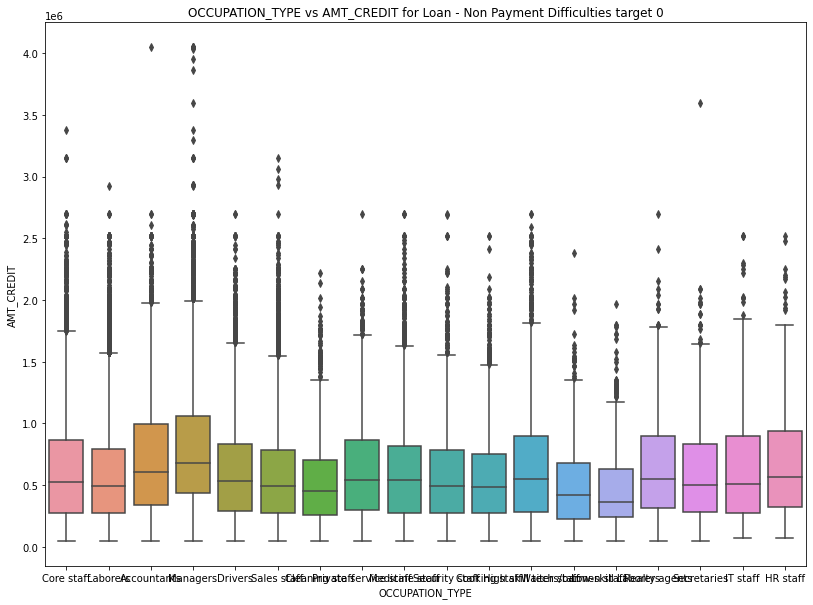

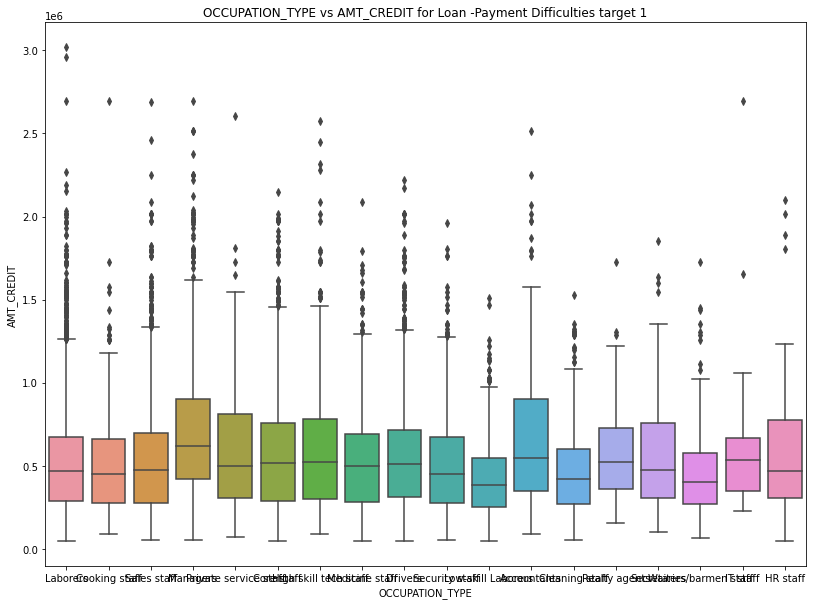

In [382]:
plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title('OCCUPATION_TYPE vs AMT_CREDIT for Loan - Non Payment Difficulties target 0')
sns.boxplot(x=data1['OCCUPATION_TYPE'],y=data1['AMT_CREDIT'])

# OCCUPATION_TYPE vs 'AMT_CREDIT' for Loan - Non Payment Difficulties
plt.figure(figsize=[30,10])
plt.subplot(1,2,2)
plt.title('OCCUPATION_TYPE vs AMT_CREDIT for Loan -Payment Difficulties target 1')
sns.boxplot(x=data2['OCCUPATION_TYPE'],y=data2['AMT_CREDIT'])

plt.show()

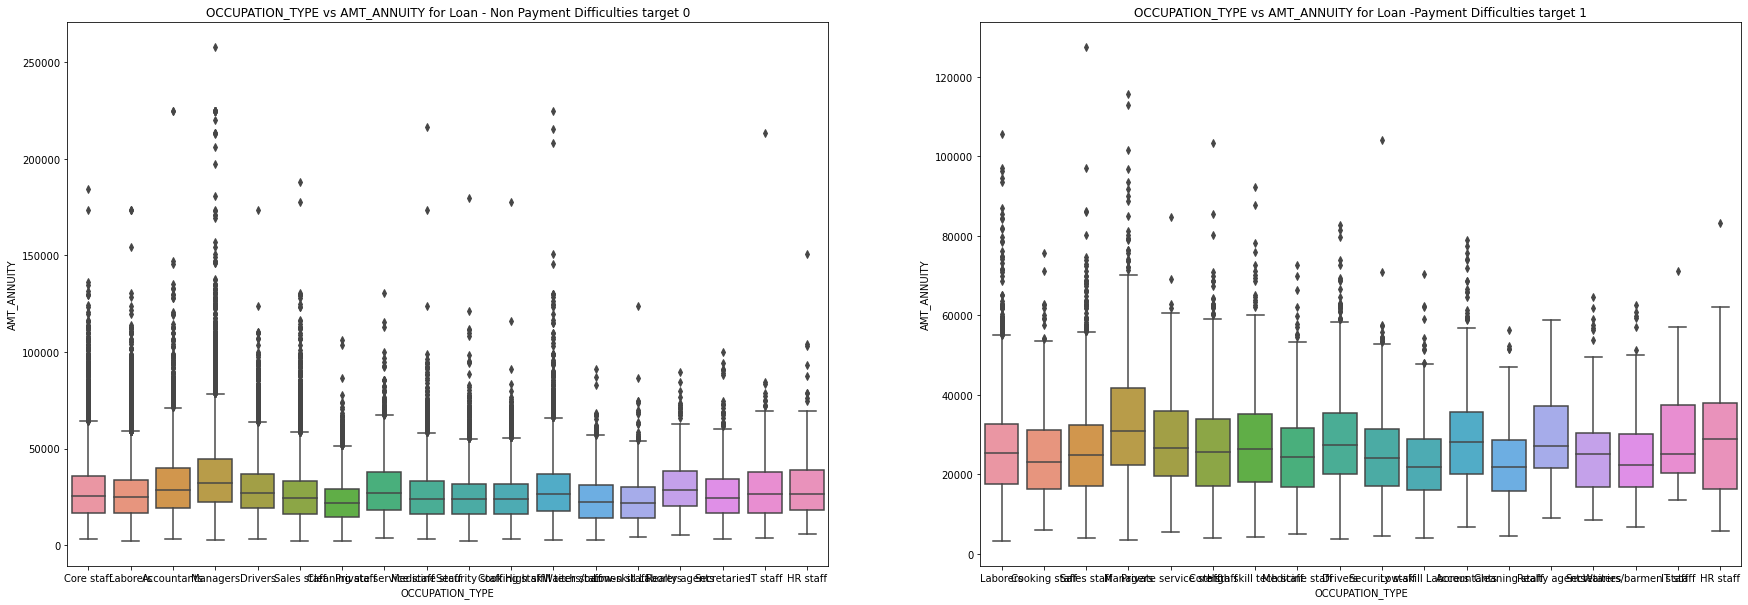

In [383]:
plt.figure(figsize=[30,10])
plt.subplot(1,2,1)
plt.title('OCCUPATION_TYPE vs AMT_ANNUITY for Loan - Non Payment Difficulties target 0')
sns.boxplot(x=data1['OCCUPATION_TYPE'],y=data1['AMT_ANNUITY'])


plt.subplot(1,2,2)
plt.title('OCCUPATION_TYPE vs AMT_ANNUITY for Loan -Payment Difficulties target 1')
sns.boxplot(x=data2['OCCUPATION_TYPE'],y=data2['AMT_ANNUITY'])
plt.show()

As in india we believe in god and many of us feel in act of god,some say todays not good day, or is supersticiousIf iam superstitious i would say tuesday, working day is not good

 <div class="alert alert-block alert-info">
<font size="5"> Bivariate Analysis of Categorical-Categorical</font>
</div>    

In [384]:
#Analysing relationship of AMT_CREDIT with Gender and Income type for Target 0

print("---------------------------------target 0----------------------------------------------")
print()
res=pd.pivot_table(data=data1, index='NAME_INCOME_TYPE',columns='CODE_GENDER',values='AMT_CREDIT', aggfunc="mean")
print(round(res,0))
#Analysing relationship of AMT_CREDIT with Gender and Income type for Target 0

res1=pd.pivot_table(data=data2, index="NAME_INCOME_TYPE",columns='CODE_GENDER',values='AMT_CREDIT', aggfunc="mean")
print()
print("---------------------------------target 1----------------------------------------------")
print(round(res1,0))


---------------------------------target 0----------------------------------------------

CODE_GENDER                   F          M
NAME_INCOME_TYPE                          
Businessman           1125000.0  1272857.0
Commercial associate   668844.0   685304.0
Maternity leave        562500.0   765000.0
Pensioner              535162.0   571540.0
State servant          665132.0   695357.0
Student                372556.0   598753.0
Unemployed             787909.0  1045500.0
Working                577846.0   587183.0

---------------------------------target 1----------------------------------------------
CODE_GENDER                  F         M
NAME_INCOME_TYPE                        
Commercial associate  613418.0  599682.0
Maternity leave       929250.0       NaN
Pensioner             558498.0  556645.0
State servant         614062.0  616407.0
Unemployed            653250.0  546750.0
Working               537035.0  533821.0


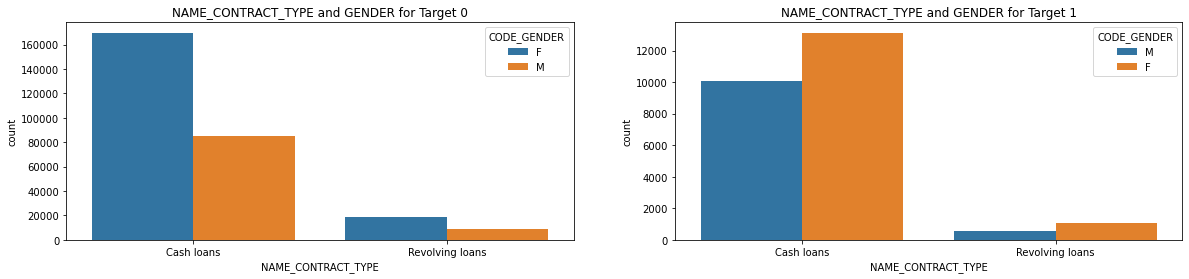

In [385]:
#Bivariate categorical and categorical

plt.figure(figsize = (20,4))
plt.subplot(1,2,1)
plt.title("NAME_CONTRACT_TYPE and GENDER for Target 0")

sns.countplot('NAME_CONTRACT_TYPE', hue = 'CODE_GENDER', data =data1)

plt.subplot(1,2,2)
plt.title("NAME_CONTRACT_TYPE and GENDER for Target 1")
sns.countplot('NAME_CONTRACT_TYPE', hue = 'CODE_GENDER', data =data2)

plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
     . Females applies for more loans
     . Male applicants are lower, ratio of male applicants deafulting is higher. Let us check this by another analysis
</div>

     

 


     

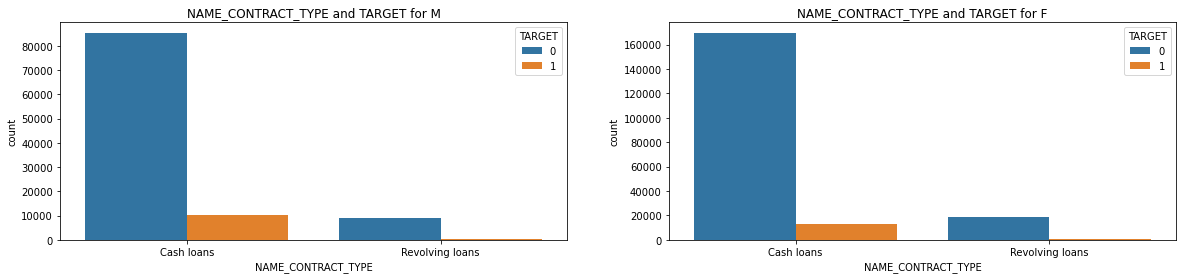

In [386]:
plt.figure(figsize = (20,4))
plt.subplot(1,2,1)
plt.title("NAME_CONTRACT_TYPE and TARGET for M")

sns.countplot('NAME_CONTRACT_TYPE', hue = "TARGET", data=df1[(df1['CODE_GENDER']=="M")])

plt.subplot(1,2,2)
plt.title("NAME_CONTRACT_TYPE and TARGET for F")
sns.countplot('NAME_CONTRACT_TYPE', hue = "TARGET", data=df1[(df1['CODE_GENDER']=="F")])

plt.show()


<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
          . Male applicants are more defaulter than female applicants
</div>

     

 


AMT_INCOME_RANGE,'NAME_INCOME_TYPE','NAME_CONTRACT_TYPE','NAME_EDUCATION_TYPE','OCCUPATION_TYPE

In [387]:
t1= pd.pivot_table(df1, values='TARGET', index=['CODE_GENDER','AMT_INCOME_TOTAL_RANGE'],columns=['NAME_EDUCATION_TYPE'], aggfunc=np.mean)

In [388]:
t1

NAME_EDUCATION_TYPE                 Academic degree  Higher education  \
CODE_GENDER AMT_INCOME_TOTAL_RANGE                                      
F           VeryLow                        0.000000          0.056068   
            Low                            0.000000          0.049026   
            Medium                         0.000000          0.050254   
            High                           0.105263          0.041516   
            VeryHigh                       0.076923          0.037289   
M           VeryLow                        0.000000          0.080411   
            Low                            0.000000          0.073305   
            Medium                         0.000000          0.070086   
            High                           0.000000          0.055911   
            VeryHigh                       0.000000          0.044080   

NAME_EDUCATION_TYPE                 Incomplete higher  Lower secondary  \
CODE_GENDER AMT_INCOME_TOTAL_RANGE                                       
F           VeryLow                          0.086399         0.080193   
            Low                              0.080075         0.113889   
            Medium                           0.078431         0.096983   
            High                             0.074434         0.038961   
            VeryHigh                         0.082251         0.066667   
M           VeryLow                          0.123967         0.125000   
            Low                              0.097778         0.142857   
            Medium                           0.095130         0.150515   
            High                             0.074627         0.081633   
            VeryHigh                         0.077586         0.064516   

NAME_EDUCATION_TYPE                 Secondary / secondary special  
CODE_GENDER AMT_INCOME_TOTAL_RANGE                                 
F           VeryLow                                      0.076778  
            Low                                          0.079523  
            Medium                                       0.075695  
            High                                         0.070736  
            VeryHigh                                     0.065930  
M           VeryLow                                      0.118066  
            Low                                          0.123693  
            Medium                                       0.113466  
            High                                         0.093484  
            VeryHigh                                     0.089939

In [389]:
t2= pd.pivot_table(df1, values='TARGET', index=['NAME_INCOME_TYPE','AMT_INCOME_TOTAL_RANGE'],columns=['NAME_EDUCATION_TYPE'], aggfunc=np.mean)

In [390]:
t2

NAME_EDUCATION_TYPE                          Academic degree  \
NAME_INCOME_TYPE     AMT_INCOME_TOTAL_RANGE                    
Businessman          Medium                              NaN   
                     VeryHigh                            NaN   
Commercial associate VeryLow                        0.000000   
                     Low                            0.000000   
                     Medium                         0.000000   
                     High                           0.083333   
                     VeryHigh                       0.000000   
Maternity leave      VeryLow                             NaN   
                     Low                                 NaN   
                     VeryHigh                            NaN   
Pensioner            VeryLow                        0.000000   
                     Low                            0.000000   
                     Medium                         0.000000   
                     High                           0.000000   
                     VeryHigh                       0.000000   
State servant        VeryLow                        0.000000   
                     Low                            0.000000   
                     Medium                         0.000000   
                     High                           0.000000   
                     VeryHigh                       0.000000   
Student              VeryLow                             NaN   
                     Low                                 NaN   
                     Medium                              NaN   
                     VeryHigh                            NaN   
Unemployed           VeryLow                             NaN   
                     Low                                 NaN   
                     Medium                              NaN   
                     High                                NaN   
Working              VeryLow                        0.000000   
                     Low                            0.000000   
                     Medium                         0.000000   
                     High                           0.071429   
                     VeryHigh                       0.100000   

NAME_EDUCATION_TYPE                          Higher education  \
NAME_INCOME_TYPE     AMT_INCOME_TOTAL_RANGE                     
Businessman          Medium                          0.000000   
                     VeryHigh                        0.000000   
Commercial associate VeryLow                         0.063924   
                     Low                             0.054673   
                     Medium                          0.056147   
                     High                            0.045373   
                     VeryHigh                        0.041612   
Maternity leave      VeryLow                         0.000000   
                     Low                             0.000000   
                     VeryHigh                        0.000000   
Pensioner            VeryLow                         0.041103   
                     Low                             0.040734   
                     Medium                          0.046927   
                     High                            0.027368   
                     VeryHigh                        0.044681   
State servant        VeryLow                         0.036471   
                     Low                             0.051593   
                     Medium                          0.036817   
                     High                            0.039123   
                     VeryHigh                        0.018337   
Student              VeryLow                              NaN   
                     Low                             0.000000   
                     Medium                          0.000000   
                     VeryHigh                        0.000000   
Unemployed           VeryLow                         0.000000   
    

In [391]:
df1['AMT_CREDIT_bins'] = pd.qcut(df1['AMT_CREDIT'], q=[0, 0.2, 0.5, 0.8, 0.95, 1], labels=['VeryLow', 'Low', "Medium", 'High', 'VeryHigh'])


In [392]:
df1['AMT_CREDIT_bins'].head()

0        Low
1       High
2    VeryLow
3        Low
4        Low
Name: AMT_CREDIT_bins, dtype: category
Categories (5, object): ['VeryLow' < 'Low' < 'Medium' < 'High' < 'VeryHigh']

In [393]:
t3= pd.pivot_table(df1, values='TARGET', index=['NAME_INCOME_TYPE','AMT_INCOME_TOTAL_RANGE'],columns=['AMT_CREDIT_bins'], aggfunc=np.mean)

In [394]:
t3

AMT_CREDIT_bins                               VeryLow       Low    Medium  \
NAME_INCOME_TYPE     AMT_INCOME_TOTAL_RANGE                                 
Businessman          Medium                  0.000000  0.000000  0.000000   
                     VeryHigh                     NaN       NaN  0.000000   
Commercial associate VeryLow                 0.075042  0.100601  0.091429   
                     Low                     0.079579  0.088039  0.087179   
                     Medium                  0.071588  0.081998  0.082316   
                     High                    0.064389  0.068212  0.073351   
                     VeryHigh                0.068345  0.064230  0.059166   
Maternity leave      VeryLow                      NaN  0.500000       NaN   
                     Low                          NaN       NaN  0.000000   
                     VeryHigh                     NaN       NaN  0.000000   
Pensioner            VeryLow                 0.038968  0.060933  0.061390   
                     Low                     0.041264  0.058859  0.061609   
                     Medium                  0.049229  0.060512  0.061063   
                     High                    0.038194  0.054889  0.062185   
                     VeryHigh                0.078947  0.076923  0.051118   
State servant        VeryLow                 0.056618  0.077173  0.072495   
                     Low                     0.053827  0.064479  0.073009   
                     Medium                  0.048805  0.062880  0.065886   
                     High                    0.045045  0.045775  0.050881   
                     VeryHigh                0.034483  0.032258  0.050420   
Student              VeryLow                 0.000000  0.000000  0.000000   
                     Low                          NaN  0.000000  0.000000   
                     Medium                  0.000000  0.000000  0.000000   
                     VeryHigh                     NaN  0.000000       NaN   
Unemployed           VeryLow                      NaN  1.000000  0.571429   
                     Low                          NaN  0.333333  0.000000   
                     Medium                       NaN       NaN  0.000000   
                     High                    0.000000       NaN  0.000000   
Working              VeryLow                 0.086225  0.122548  0.102866   
                     Low                     0.089927  0.112331  0.103705   
                     Medium                  0.088613  0.105577  0.105983   
                     High                    0.075838  0.093788  0.093102   
                     VeryHigh                0.082305  0.099644  0.081644   

AMT_CREDIT_bins                                  High  VeryHigh  
NAME_INCOME_TYPE     AMT_INCOME_TOTAL_RANGE                      
Businessman          Medium                       NaN  0.000000  
                     VeryHigh                0.000000  0.000000  
Commercial associate VeryLow                 0.069606  0.000000  
                     Low                     0.069608  0.049505  
                     Medium                  0.067073  0.043582  
                     High                    0.056584  0.043629  
                     VeryHigh                0.051844  0.040323  
Maternity leave      VeryLow                      NaN  1.000000  
                     Low                          NaN       NaN  
                     VeryHigh                     NaN       NaN  
Pensioner            VeryLow                 0.070976  0.084906  
                     Low                     0.060073  0.047198  
                     Medium                  0.047082  0.051704  
                     High                    0.039239  0.030000  
                     VeryHigh                0.044693  0.051282  
State servant        VeryLow                 0.057034  0.083333  
                     Low                     0.065651  0.035971  
                     Medium                  0.053

 <div class="alert alert-block alert-info">
<font size="5">Analysing more data2 variable- which is having loan repayment difficulty group of peoplel</font>
</div>     

In [395]:
detectfraud2=pd.pivot_table(data2, values='TARGET', index=['REGION_RATING_CLIENT'],aggfunc=np.sum)
detectfraud2
#rating 2 type people have payment difficulties

,TARGET
REGION_RATING_CLIENT,
1,1552
2,17907
3,5366


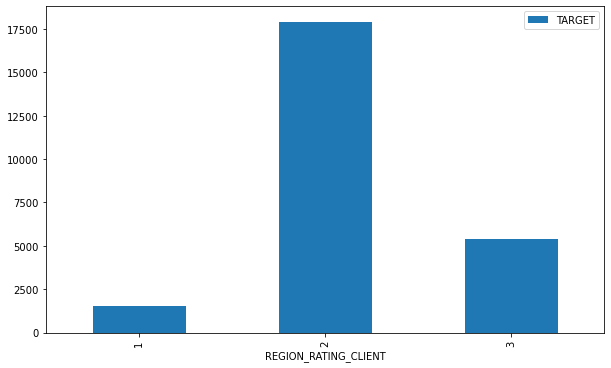

In [396]:
detectfraud2.plot(kind="bar", stacked="True", figsize=[10,6])
plt.show()

In [397]:
detectfraud2_3=pd.pivot_table(data1, values='TARGET', index=['REGION_RATING_CLIENT'],aggfunc=np.sum)
detectfraud2_3
#rating 2 type people have payment difficulties

,TARGET
REGION_RATING_CLIENT,
1,0
2,0
3,0


 <div class="alert alert-block alert-info">
<font size="5"> Gender Distibution of applicant having payment Difficulties</font>
</div>     

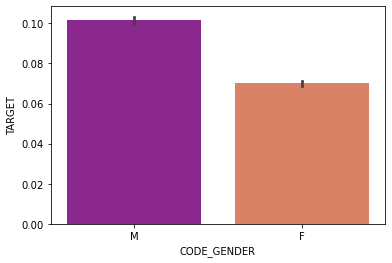

In [398]:


sns.barplot(x ='CODE_GENDER', y ='TARGET', data = df1, 
            palette ='plasma')
plt.show()

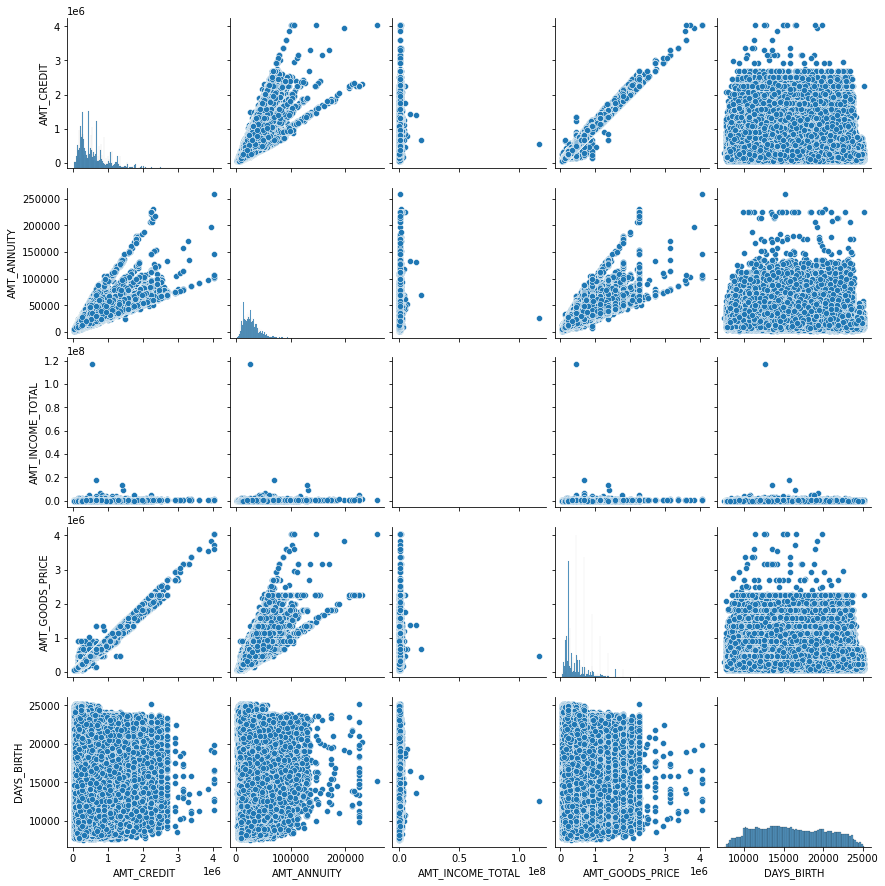

In [399]:
pair = df1[['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH']].fillna(0)
sns.pairplot(pair)

plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
      . Among people having no payment difficulty

      
      Strong Positive correlation is experienced among:
      . Amt_goods_price, amt_credit, makes sense as loan is being taken for apllied goods only by applicant
    
      . Amt_annuity and amt_income total, makes sense as less income people has more tendency to take loan
    
    . Days_birt and amt_credit, senior most people are having less amt_credit
</div>

     

    
    
    
    

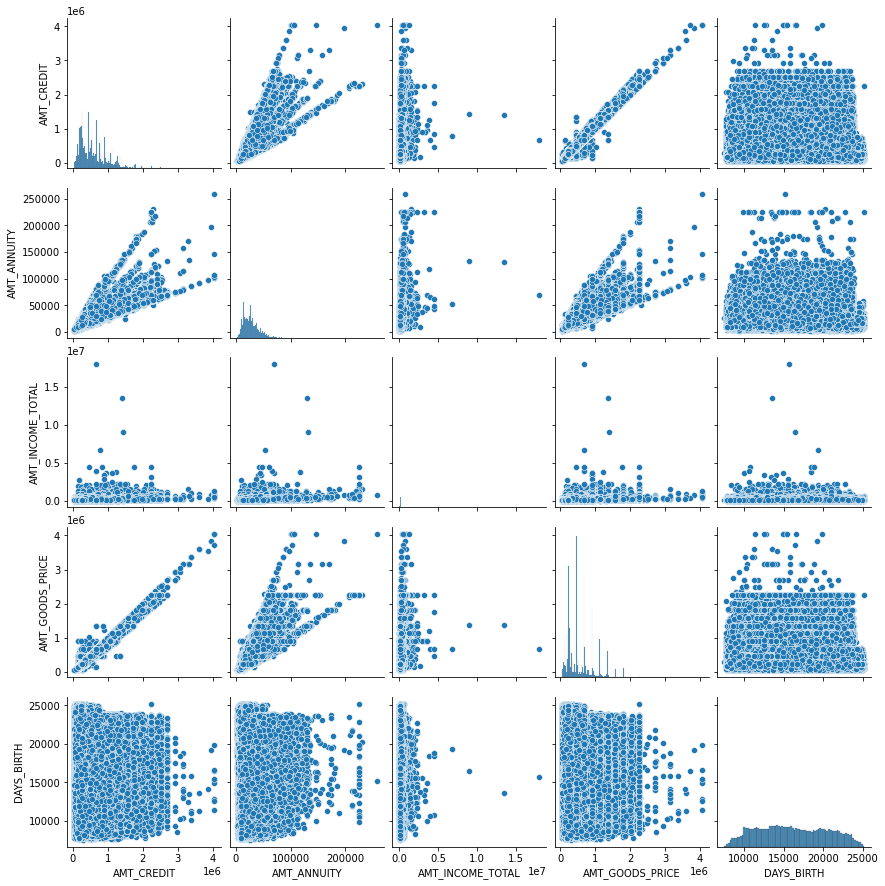

In [400]:
#Pairplot for Target 1 (Loan-Payment Difficulties)
pair = data1[['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH']].fillna(0)
sns.pairplot(pair)

plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
      .AMT_CREDIt and AMT_GOOD PRICE dont seem to be increasing in ratio  with AMT_INCOME for TARGET 1, might be reason for  possible default.
</div>

     

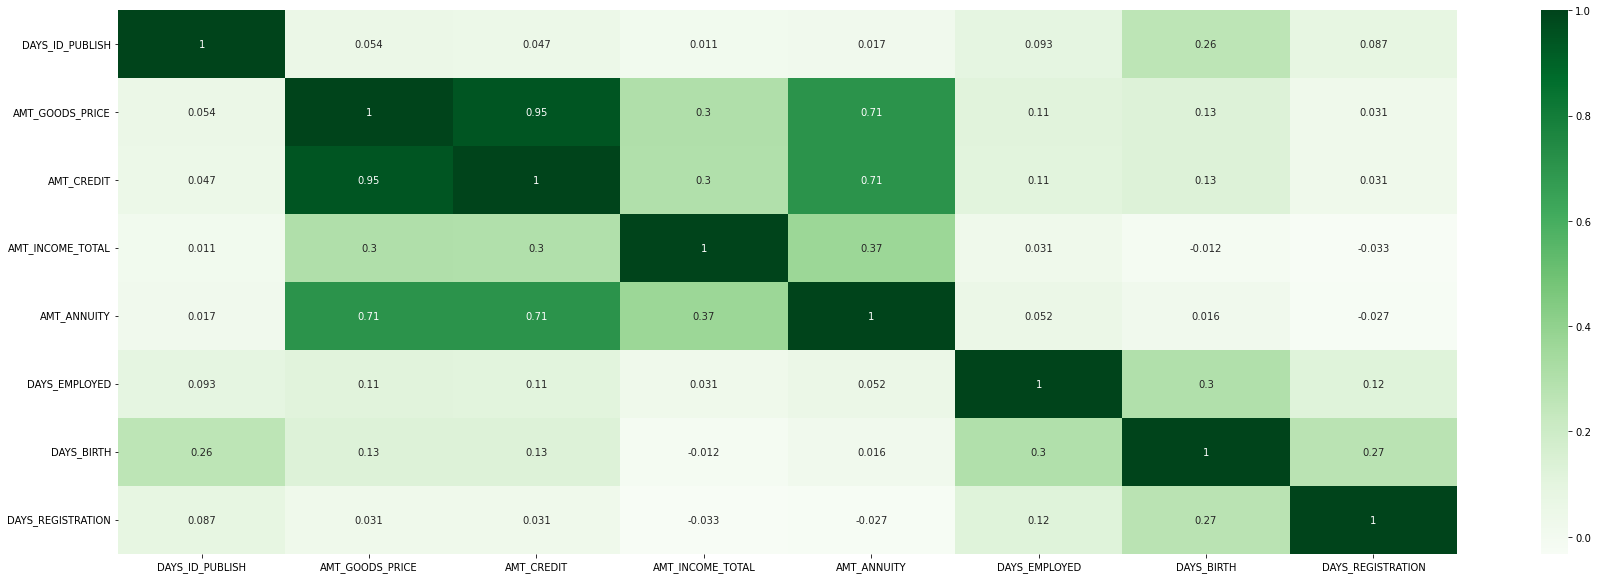

In [401]:
# Heatmap for Loan- Non Payment Difficulties
plt.figure(figsize=[30,10])
da0=data1[['DAYS_EMPLOYED','DAYS_BIRTH','DAYS_ID_PUBLISH','AMT_GOODS_PRICE','AMT_INCOME_TOTAL','AMT_ANNUITY',
         'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
         'AMT_CREDIT',]].corr(method = 'pearson')
sns.heatmap(da,cmap="Greens", annot=True)
plt.show()

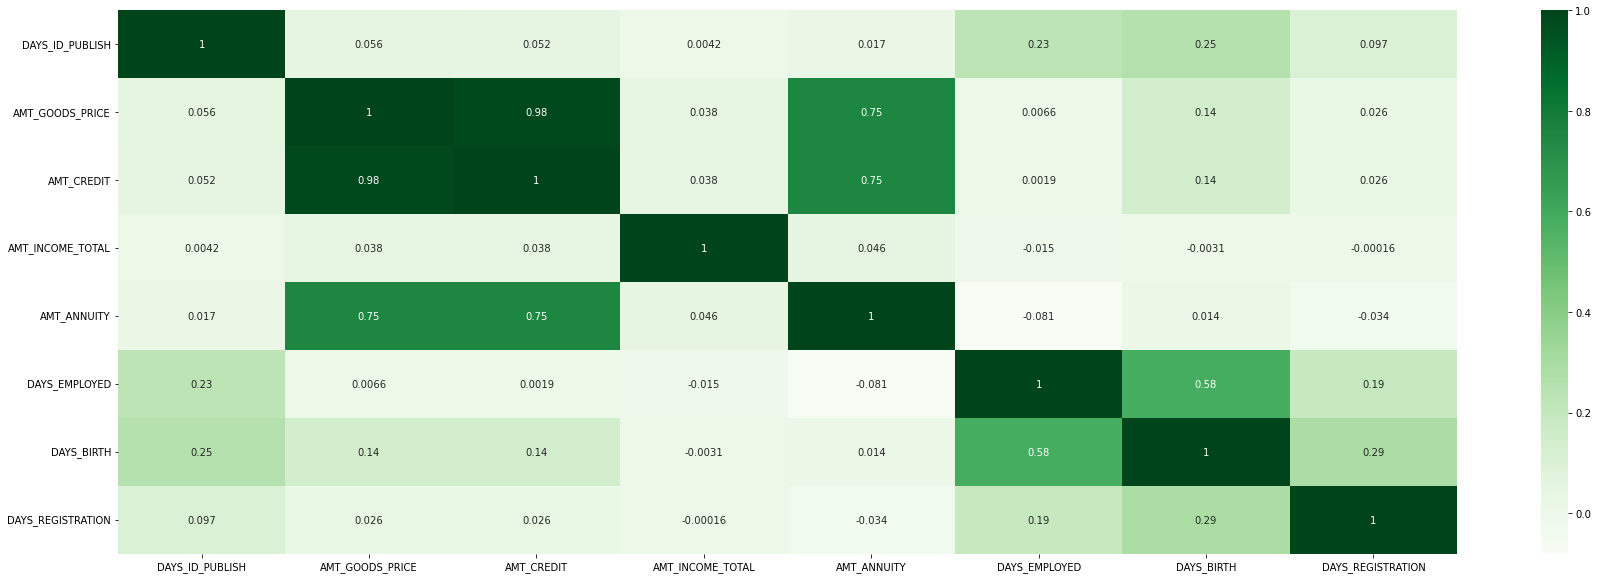

In [402]:
# Heatmap for Loan-Payment Difficulties
plt.figure(figsize=[30,10])
da=data2[['DAYS_ID_PUBLISH','AMT_GOODS_PRICE','AMT_CREDIT','AMT_INCOME_TOTAL','AMT_ANNUITY','DAYS_EMPLOYED',
  'DAYS_BIRTH', 'DAYS_REGISTRATION', 
  ]].corr()
sns.heatmap(da,cmap="Greens", annot=True)
plt.show()

<div class="alert alert-block alert-info">
<font size="5"> <font color = red> Finding top Correlations for target 0</font>
</div>       

In [403]:
#correlation for Target 0

df_corr_data1=data1.corr().abs()
df_corr_data1

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,applicant_age
SK_ID_CURR,1.000000,NaN,0.000716,0.001739,0.000342,0.000071,0.000235,0.000360,0.001346,0.001744,...,0.000676,0.000832,0.000485,0.001879,0.001725,0.002524,0.000054,0.001148,0.004349,0.001318
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,0.000716,NaN,1.000000,0.027397,0.003081,0.020909,0.000559,0.024363,0.336966,0.245174,...,0.001078,0.001302,0.002983,0.000432,0.000648,0.001632,0.010455,0.007087,0.042547,0.336907
AMT_INCOME_TOTAL,0.001739,NaN,0.027397,1.000000,0.342799,0.418948,0.349426,0.167851,0.062609,0.140392,...,0.005762,0.000840,0.000869,0.001417,0.007862,0.006234,0.061470,0.013128,0.029536,0.062494
AMT_CREDIT,0.000342,NaN,0.003081,0.342799,1.000000,0.771297,0.987022,0.100604,0.047378,0.070104,...,0.021560,0.032151,0.015602,0.003734,0.004409,0.001883,0.054071,0.017767,0.048866,0.047366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,0.002524,NaN,0.001632,0.006234,0.001883,0.012671,0.001578,0.002480,0.001069,0.002223,...,0.001068,0.001550,0.000571,0.004576,0.220087,1.000000,0.014248,0.015466,0.019085,0.001171
AMT_REQ_CREDIT_BUREAU_MON,0.000054,NaN,0.010455,0.061470,0.054071,0.038178,0.055880,0.078629,0.002855,0.034890,...,0.002476,0.001379,0.003246,0.000528,0.004753,0.014248,1.000000,0.008160,0.004889,0.002729
AMT_REQ_CREDIT_BUREAU_QRT,0.001148,NaN,0.007087,0.013128,0.017767,0.011248,0.018177,0.001013,0.011335,0.015116,...,0.001503,0.001212,0.002175,0.003350,0.004749,0.015466,0.008160,1.000000,0.074664,0.011297
AMT_REQ_CREDIT_BUREAU_YEAR,0.004349,NaN,0.042547,0.029536,0.048866,0.010886,0.051206,0.001775,0.072886,0.052169,...,0.006395,0.011754,0.005188,0.004790,0.003798,0.019085,0.004889,0.074664,1.000000,0.072847


In [404]:
corr_df = df_corr_data1.where(np.triu(np.ones(df_corr_data1.shape),k=1).astype(np.bool)).unstack().reset_index()
corr_df.columns=['Column1','Column2','Correlation']
corr_df.dropna(subset = ['Correlation'], inplace = True)
corr_df = corr_df.sort_values(by=['Correlation'], ascending=False)

corr_df.head(10)

,Column1,Column2,Correlation
815,FLAG_EMP_PHONE,DAYS_EMPLOYED,0.999756
3790,applicant_age,DAYS_BIRTH,0.999711
2014,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.998508
376,AMT_GOODS_PRICE,AMT_CREDIT,0.987022
1259,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.950149
1118,CNT_FAM_MEMBERS,CNT_CHILDREN,0.878571
1511,LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.861861
2077,DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.859332
1700,LIVE_CITY_NOT_WORK_CITY,REG_CITY_NOT_WORK_CITY,0.830381
377,AMT_GOODS_PRICE,AMT_ANNUITY,0.776421


<div class="alert alert-block alert-info">
<font size="5"> <font color = red> Finding Top Correlations for target 1</font>
</div>      

In [405]:
#correlation for Target 1
df_corr_data2=data2.corr().abs()
corr_df1 = df_corr_data2.where(np.triu(np.ones(df_corr_data2.shape),k=1).astype(np.bool)).unstack().reset_index()
corr_df1.columns=['attribute1','attribute2','Correlation']
corr_df1.dropna(subset = ['Correlation'], inplace = True)
corr_df1 = corr_df.sort_values(by=['Correlation'], ascending=False)

corr_df1.head(10)

,Column1,Column2,Correlation
815,FLAG_EMP_PHONE,DAYS_EMPLOYED,0.999756
3790,applicant_age,DAYS_BIRTH,0.999711
2014,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.998508
376,AMT_GOODS_PRICE,AMT_CREDIT,0.987022
1259,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.950149
1118,CNT_FAM_MEMBERS,CNT_CHILDREN,0.878571
1511,LIVE_REGION_NOT_WORK_REGION,REG_REGION_NOT_WORK_REGION,0.861861
2077,DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.859332
1700,LIVE_CITY_NOT_WORK_CITY,REG_CITY_NOT_WORK_CITY,0.830381
377,AMT_GOODS_PRICE,AMT_ANNUITY,0.776421


We notice  that the TOP  correlation attribute- These are same for Target 1 and Target 0 dataframes


 <div class="alert alert-block alert-info">
<font size="5"> Not in scope for now</font>
</div>     

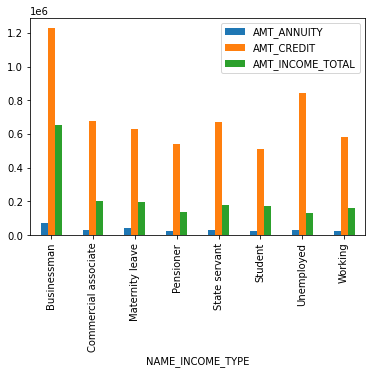

In [406]:
z=pd.pivot_table(data1,index='NAME_INCOME_TYPE',values=['AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL'])
z.plot.bar()
plt.show()

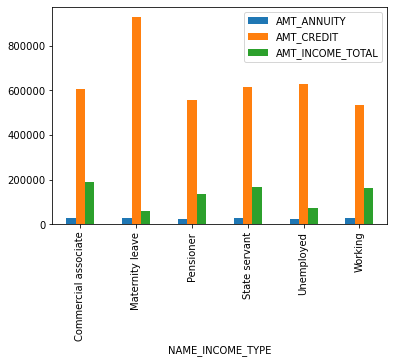

In [407]:
z=pd.pivot_table(data2,index='NAME_INCOME_TYPE',values=['AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL'])
z.plot.bar()
plt.show()

Assuming clients retiring age is 60 years.And assuming avg applicant savings is 30%
if (60-clients age)*Amt_annuity+(in years the client is working before taking loan * (client_annual_income*.30) < amt_credit
than this are surely will be bank defaulter.

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . In 'NAME INCOME TYPE,' the number of 'Maternity Leave' is relatively low, and it also has the highest percentage of payment  difficulties—around 40%. As a result, clients whose income type is 'Maternity leave' are the most likely to default on their   loans.

    . In 'OCCUPATION TYPE,' the number of 'Low skilled Laborers' is comparatively low, and it also has the highest percent of   payment difficultiesapproximately 17%. As a result, clients who work as 'Low skilled Laborers' are the most likely to default   on their loans.

    . The number of 'Lower Secondary' students in 'NAME EDUCATION TYPE' is rather low, and it also has the highest percentage of payment difficulties—around 11%. As a result, clients with a 'Lower Secondary' education are the most likely to default on their loans.
</div>

   

     

 <div class="alert alert-block alert-info">
<font size="5"> Analysis of previous data</font>
</div>     

## <font color =red> Data Loading

In [408]:
df2=pd.read_csv("previous_application.csv")

In [409]:
df2.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [410]:
df2.shape

(1670214, 37)

 <div class="alert alert-block alert-info">
<font size="5"> <font color =green>  Cleaning of data - Missing Values</font>
</div>      


In [411]:
# Checking columns with  missing values

df2.isnull().sum()

SK_ID_PREV                           0
SK_ID_CURR                           0
NAME_CONTRACT_TYPE                   0
AMT_ANNUITY                     372235
AMT_APPLICATION                      0
AMT_CREDIT                           1
AMT_DOWN_PAYMENT                895844
AMT_GOODS_PRICE                 385515
WEEKDAY_APPR_PROCESS_START           0
HOUR_APPR_PROCESS_START              0
FLAG_LAST_APPL_PER_CONTRACT          0
NFLAG_LAST_APPL_IN_DAY               0
RATE_DOWN_PAYMENT               895844
RATE_INTEREST_PRIMARY          1664263
RATE_INTEREST_PRIVILEGED       1664263
NAME_CASH_LOAN_PURPOSE               0
NAME_CONTRACT_STATUS                 0
DAYS_DECISION                        0
NAME_PAYMENT_TYPE                    0
CODE_REJECT_REASON                   0
NAME_TYPE_SUITE                 820405
NAME_CLIENT_TYPE                     0
NAME_GOODS_CATEGORY                  0
NAME_PORTFOLIO                       0
NAME_PRODUCT_TYPE                    0
CHANNEL_TYPE             

In [412]:
# Checking % of missing values

df2.isnull().sum()/len(df2)*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                    22.286665
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000060
AMT_DOWN_PAYMENT               53.636480
AMT_GOODS_PRICE                23.081773
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              53.636480
RATE_INTEREST_PRIMARY          99.643698
RATE_INTEREST_PRIVILEGED       99.643698
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                49.119754
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

 <div class="alert alert-block alert-info">
<font size="5">  Handling Missing Values </font>
</div>      


In [413]:
#Drop na values from amt_annuity and amt_goods_price

df2 = df2.dropna(axis=0, subset=['AMT_ANNUITY'])
df2 = df2.dropna(axis=0, subset=['AMT_GOODS_PRICE'])
df2.isnull().sum()/len(df2)*100

SK_ID_PREV                      0.000000
SK_ID_CURR                      0.000000
NAME_CONTRACT_TYPE              0.000000
AMT_ANNUITY                     0.000000
AMT_APPLICATION                 0.000000
AMT_CREDIT                      0.000000
AMT_DOWN_PAYMENT               40.546489
AMT_GOODS_PRICE                 0.000000
WEEKDAY_APPR_PROCESS_START      0.000000
HOUR_APPR_PROCESS_START         0.000000
FLAG_LAST_APPL_PER_CONTRACT     0.000000
NFLAG_LAST_APPL_IN_DAY          0.000000
RATE_DOWN_PAYMENT              40.546489
RATE_INTEREST_PRIMARY          99.522595
RATE_INTEREST_PRIVILEGED       99.522595
NAME_CASH_LOAN_PURPOSE          0.000000
NAME_CONTRACT_STATUS            0.000000
DAYS_DECISION                   0.000000
NAME_PAYMENT_TYPE               0.000000
CODE_REJECT_REASON              0.000000
NAME_TYPE_SUITE                32.647474
NAME_CLIENT_TYPE                0.000000
NAME_GOODS_CATEGORY             0.000000
NAME_PORTFOLIO                  0.000000
NAME_PRODUCT_TYP

In [414]:
xx=df2.columns.tolist()
def perc(i):
    null_values=df2[i].isnull().sum()
    total_value=df2[i].shape[0]
    null_percentage=null_values/total_value
    return null_percentage
for i in xx:
    print(i,perc(i))

SK_ID_PREV 0.0
SK_ID_CURR 0.0
NAME_CONTRACT_TYPE 0.0
AMT_ANNUITY 0.0
AMT_APPLICATION 0.0
AMT_CREDIT 0.0
AMT_DOWN_PAYMENT 0.405464888632133
AMT_GOODS_PRICE 0.0
WEEKDAY_APPR_PROCESS_START 0.0
HOUR_APPR_PROCESS_START 0.0
FLAG_LAST_APPL_PER_CONTRACT 0.0
NFLAG_LAST_APPL_IN_DAY 0.0
RATE_DOWN_PAYMENT 0.405464888632133
RATE_INTEREST_PRIMARY 0.9952259451826176
RATE_INTEREST_PRIVILEGED 0.9952259451826176
NAME_CASH_LOAN_PURPOSE 0.0
NAME_CONTRACT_STATUS 0.0
DAYS_DECISION 0.0
NAME_PAYMENT_TYPE 0.0
CODE_REJECT_REASON 0.0
NAME_TYPE_SUITE 0.32647474163938633
NAME_CLIENT_TYPE 0.0
NAME_GOODS_CATEGORY 0.0
NAME_PORTFOLIO 0.0
NAME_PRODUCT_TYPE 0.0
CHANNEL_TYPE 0.0
SELLERPLACE_AREA 0.0
NAME_SELLER_INDUSTRY 0.0
CNT_PAYMENT 0.0
NAME_YIELD_GROUP 0.0
PRODUCT_COMBINATION 0.0
DAYS_FIRST_DRAWING 0.23367594197316902
DAYS_FIRST_DUE 0.23367594197316902
DAYS_LAST_DUE_1ST_VERSION 0.23367594197316902
DAYS_LAST_DUE 0.23367594197316902
DAYS_TERMINATION 0.23367594197316902
NFLAG_INSURED_ON_APPROVAL 0.23367594197316902


  <div class="alert alert-block alert-info">
<font size="5">  Checking columns with >30% NULL values </font>
</div>      

    

In [415]:


print(df2.columns[(df2.isnull().sum() * 100 / df2.shape[0]) > 30])

Index(['AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_TYPE_SUITE'],
      dtype='object')


In [416]:
#Dropping all >30 null value columns
dropcol=df2.columns[(df2.isnull().sum() * 100 / df2.shape[0]) > 20]
df2.drop(axis=1, columns=dropcol, inplace=True)
df2.shape

(1246320, 26)

  <div class="alert alert-block alert-info">
<font size="5">   Analyzing object variable </font>
</div>      

   

In [417]:

for i in df2.columns:
    if df2[i].dtypes=="object":
        print(df2[i].value_counts(normalize=True, dropna= False))

Consumer loans     0.554779
Cash loans         0.370341
Revolving loans    0.074880
Name: NAME_CONTRACT_TYPE, dtype: float64
SATURDAY     0.152194
FRIDAY       0.149213
WEDNESDAY    0.148734
TUESDAY      0.148228
MONDAY       0.146892
THURSDAY     0.146119
SUNDAY       0.108620
Name: WEEKDAY_APPR_PROCESS_START, dtype: float64
Y    0.997222
N    0.002778
Name: FLAG_LAST_APPL_PER_CONTRACT, dtype: float64
XAP                                 0.629659
XNA                                 0.314679
Repairs                             0.019014
Other                               0.012436
Urgent needs                        0.006744
Buying a used car                   0.002304
Building a house or an annex        0.002161
Everyday expenses                   0.001921
Medicine                            0.001739
Payments on other loans             0.001545
Education                           0.001257
Journey                             0.000991
Purchase of electronic equipment    0.000846
Buying a 

  <div class="alert alert-block alert-info">
<font size="5"> Deleting columns with high percentage of xna ,nna,xap datas  </font>
</div>      

    
    NAME_PAYMENT_TYPE - 19% XAP values
    CODE_REJECT_REASON - 80% XAP values
    WEEKDAY_APPR_PROCESS_START -Not relevant
    NAME_GOODS_CATEGORY - hIGH XNA values
    NAME_PRODUCT_TYPE -55% XNA values
    CODE_REJECT_REASON - 80% XAP values
    NAME_CASH_LOAN_PURPOSE - 90% NNA / XAP values,     
    NAME_PAYMENT_TYPE - 19% XAP values
    

In [418]:
# Deleting columns mentioned above
dropcol=['WEEKDAY_APPR_PROCESS_START', 'NAME_PRODUCT_TYPE','NAME_CASH_LOAN_PURPOSE', 'NAME_GOODS_CATEGORY','NAME_PAYMENT_TYPE','CODE_REJECT_REASON']
df2.drop(axis=1, columns=dropcol, inplace=True)
df2.shape

(1246320, 20)

In [419]:
df2.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_CLIENT_TYPE,NAME_PORTFOLIO,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,17145.0,15,Y,1,Approved,-73,Repeater,POS,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,607500.0,11,Y,1,Approved,-164,Repeater,Cash,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,112500.0,11,Y,1,Approved,-301,Repeater,Cash,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,450000.0,7,Y,1,Approved,-512,Repeater,Cash,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,337500.0,9,Y,1,Refused,-781,Repeater,Cash,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high


In [420]:
# XNA and XAP are replaced by NaN
df2=df2.replace('XNA', np.NaN)
df2=df2.replace('XAP', np.NaN)

In [421]:
# Value counts of Contract Status in previous application
df2['NAME_CONTRACT_STATUS'].value_counts()

Approved        993938
Refused         240969
Canceled         10503
Unused offer       910
Name: NAME_CONTRACT_STATUS, dtype: int64

  <div class="alert alert-block alert-info">
<font size="5">  Checking only object types Variables and their values  </font>
</div> 

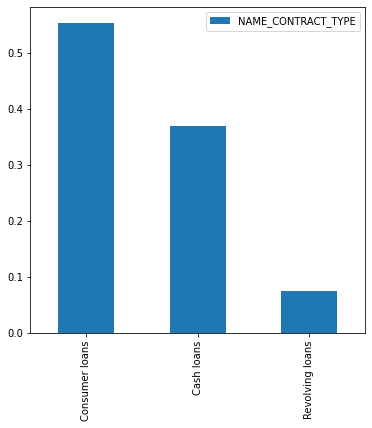

Consumer loans     0.554779
Cash loans         0.370341
Revolving loans    0.074880
Name: NAME_CONTRACT_TYPE, dtype: float64


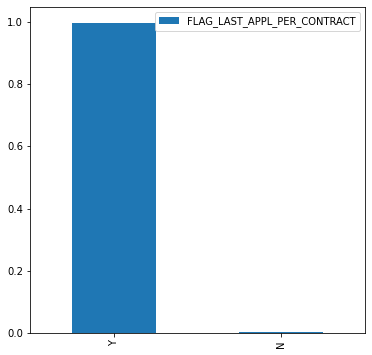

Y    0.997222
N    0.002778
Name: FLAG_LAST_APPL_PER_CONTRACT, dtype: float64


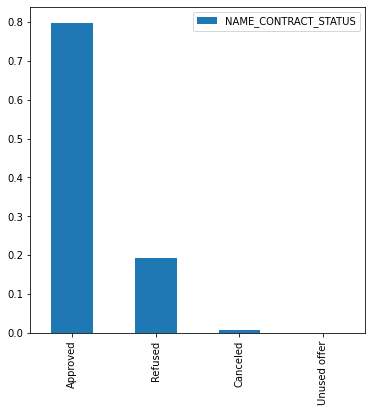

Approved        0.797498
Refused         0.193344
Canceled        0.008427
Unused offer    0.000730
Name: NAME_CONTRACT_STATUS, dtype: float64


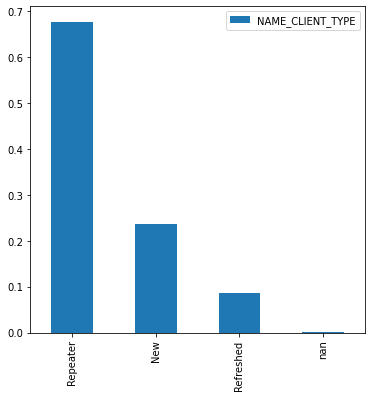

Repeater     0.677066
New          0.236334
Refreshed    0.085877
NaN          0.000723
Name: NAME_CLIENT_TYPE, dtype: float64


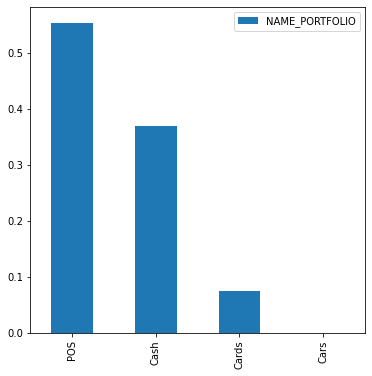

POS      0.554438
Cash     0.370341
Cards    0.074880
Cars     0.000341
Name: NAME_PORTFOLIO, dtype: float64


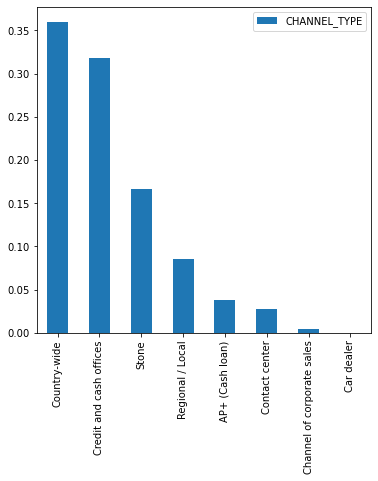

Country-wide                  0.359302
Credit and cash offices       0.317926
Stone                         0.166645
Regional / Local              0.085031
AP+ (Cash loan)               0.038082
Contact center                0.027836
Channel of corporate sales    0.004817
Car dealer                    0.000363
Name: CHANNEL_TYPE, dtype: float64


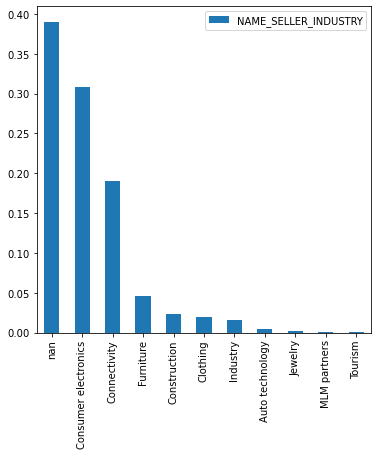

NaN                     0.389958
Consumer electronics    0.308245
Connectivity            0.190554
Furniture               0.045780
Construction            0.023736
Clothing                0.019091
Industry                0.015262
Auto technology         0.003989
Jewelry                 0.002173
MLM partners            0.000800
Tourism                 0.000412
Name: NAME_SELLER_INDUSTRY, dtype: float64


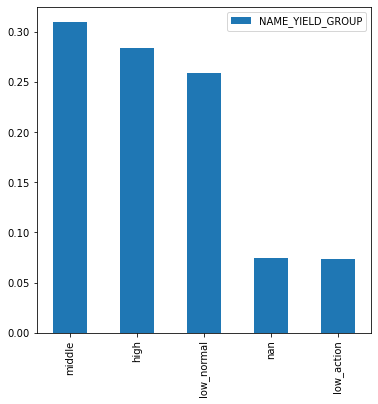

middle        0.309335
high          0.283497
low_normal    0.258437
NaN           0.074880
low_action    0.073850
Name: NAME_YIELD_GROUP, dtype: float64


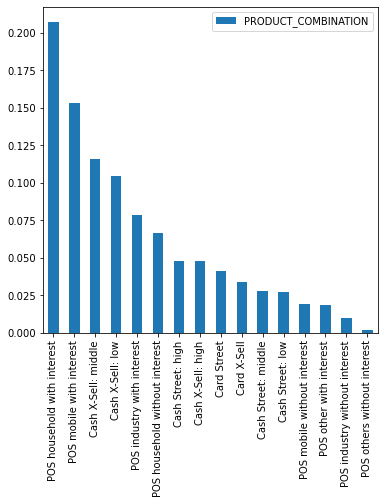

POS household with interest       0.206895
POS mobile with interest          0.152865
Cash X-Sell: middle               0.115446
Cash X-Sell: low                  0.104506
POS industry with interest        0.078757
POS household without interest    0.066522
Cash Street: high                 0.047852
Cash X-Sell: high                 0.047581
Card Street                       0.041335
Card X-Sell                       0.033545
Cash Street: middle               0.027808
Cash Street: low                  0.027147
POS mobile without interest       0.019322
POS other with interest           0.018255
POS industry without interest     0.010111
POS others without interest       0.002050
Name: PRODUCT_COMBINATION, dtype: float64


In [422]:

for i in df2.columns:
    if df2[i].dtypes=="object":
        
        plt.figure(figsize=[6,6])
        df2[i].value_counts(normalize=True, dropna=False).plot.bar()
        plt.legend()
        plt.show()
        print(df2[i].value_counts(normalize=True, dropna= False))
        
                
        

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
     1New type of loan is discovered- Consumer Loan, which was not there in Application data frame. 55.47% of loans are consumer loans. 37.03% cash loans and rest .07% are revolving
    
    Max Loan purpose is not clear as xna and xna are dominant, among rest repair is most
    xap code is the max reson for rejection
    
    Approved loans are 79% and refused, cancelled, unused - rest. **IMBALANCE IN DATA**
    
    67% are repeaters. NAME_CLIENT_TYPE also has some null values showing as XNA
    
    Less people take loan for cars and 55% of the applicants have taken loan for POS purchase.
</div>

    
  

   

    

    

    
    
    



##### **Inference**
   
    



  <div class="alert alert-block alert-info">
<font size="5">  Numerical Variable </font>
</div> 

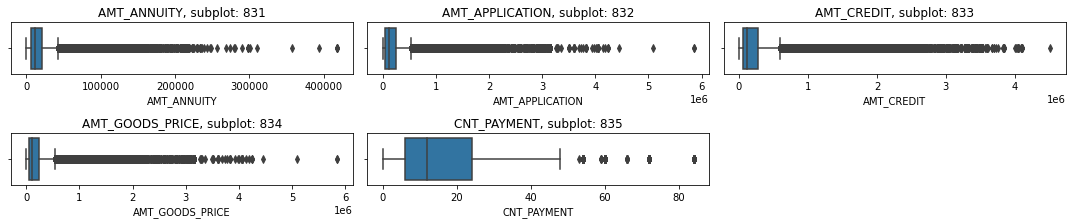

In [423]:
#  Float Data
row = 8  # number of rows
col = 3  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(15,12))

for i in df2.columns:
    if df2[i].dtypes=="float64" or df2[i].dtypes=="float32" :
        plt.subplot(row, col, c)
        plt.title('{}, subplot: {}{}{}'.format(i, row, col, c))
        plt.xlabel(i)
        sns.boxplot(df2[i])
        c = c + 1

fig.tight_layout()
plt.show()

Continuous Variables seem to have high percentage of outliers. Checking distribution

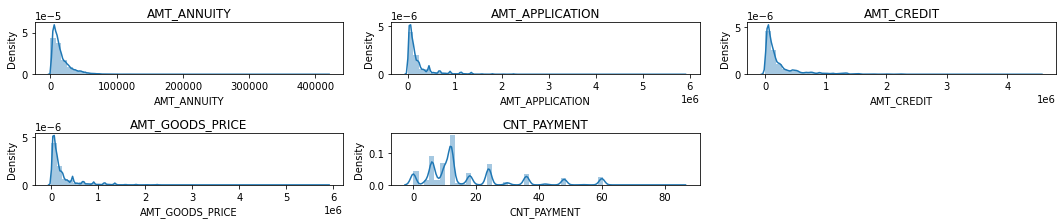

In [424]:
#  for all numerical Data
a = 8  # number of rows
b = 3  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(15,12))

for i in df2.columns:
    if df2[i].dtypes=="float64" or df2[i].dtypes=="float32" :
        plt.subplot(a, b, c)
        plt.title(i)
        plt.xlabel(i)
        
        sns.distplot(a=df2[i])
        c = c + 1

fig.tight_layout()
plt.show()

  <div class="alert alert-block alert-info">
<font size="5"> Outlier & Possible Treatment </font>
</div> 

    AMT_ANNUITY : (61959, 16) Percentage of Outlier rows:  4.97
    CNT_PAYMENT : (103224, 16) Percentage of Outlier rows:  8.28
    AMT_GOODS_PRICE : (75714, 16) Percentage of Outlier rows:  6.08
    AMT_APPLICATION : (75698, 16) Percentage of Outlier rows:  6.07
    AMT_CREDIT : (69957, 16) Percentage of Outlier rows:  5.61
    
    

  <div class="alert alert-block alert-info">
<font size="5"> <font color=red> Bivariate Analysis</font>
</div> 

  <div class="alert alert-block alert-info">
<font size="5"> Categorical and Categorical Variable </font>
</div> 

In [ ]:
cols=['NAME_CONTRACT_TYPE','NAME_CLIENT_TYPE','NAME_PORTFOLIO']


a = 4  # number of rows
b = 2  # number of columns
c = 1  # initialize plot counter

fig = plt.figure(figsize=(20,15))

for i in cols:

    plt.subplot(a, b, c)
    plt.title(i)
    plt.xlabel(i)
    sns.countplot(x=i, data=df2, hue='NAME_CONTRACT_STATUS')
    c = c + 1

fig.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    Maximum number of loan for consumer loans is approved
    Repeated people has most  approved loan
    Max approved Pos transaction
    Cancelled: Minimum for consumer loan, next is revolving than cash loans
    more cash loans have been refused than POS and cards.
</div>

    
  

   

    

    

    
    
    




  <div class="alert alert-block alert-info">
<font size="5"> <font color = red> Top Correlations</font>
</div> 

In [ ]:
df_corr_prev_df2=df2.drop(axis=1,columns=['SK_ID_CURR','SK_ID_PREV'] )

correlation=df_corr_prev_df2.corr().abs()

In [ ]:

#finding top correlations
corr_prev = correlation.where(np.triu(np.ones(correlation.shape),k=1).astype(np.bool)).unstack().reset_index()
corr_prev.columns=['attribute1','attribute2','Correlation']
corr_prev.dropna(subset=['Correlation'],inplace=True)
corr_prev = corr_prev.sort_values(by=['Correlation'], ascending=False)

corr_prev


In [ ]:
plt.figure(figsize=[20,8])
sns.pairplot(df2[['AMT_GOODS_PRICE','AMT_APPLICATION','AMT_CREDIT','AMT_ANNUITY','CNT_PAYMENT']])
plt.show()    
    
    

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . AMT_GOODS_PRICE, AMT_APPLICATION ,AMT_ANNUITY, -strong relation/correlation  makes sense as more goods purchased,
      so more load
    . One strange thing observed in Column CNT_Payment as it has low correlation with AMT_credit 
    . Similary, AMT_Credit to AMT_GOOD_PRICE has high relation/correlation
</div>

    
  

   

    

    

    
    
    



  <div class="alert alert-block alert-info">
<font size="5"> <font color=green> Multivariate Analysis</font>
</div>  

In [ ]:
# Checking contract status vs name client type aggregating over application amount

res=pd.pivot_table(data=df2, index="NAME_CONTRACT_STATUS",columns='NAME_CLIENT_TYPE',values='AMT_APPLICATION')
plt.figure(figsize=(15,8))
sns.heatmap(res, annot=True,cmap='Greens', fmt="g")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . Unused offer application amount is low, ight be no good offers is the reason
    
    . Amount of Cancelled application amount is high. Maybe because the bank is refusing these possibility because the Debt           liabiltiy ratio of consumer must be going high due to the high amount and thus credit defualt risk.
    
    . Repreater's application amount is higest than the New customers. This may indicate that the bank has more attractive           policies/rate of interest,facilities for repeat applicants
</div>

    
  

   

    

    

    

In [ ]:
# Checking contract status vs name client type aggregating over AMT CREDIT

res=pd.pivot_table(data=df2, index="NAME_CONTRACT_STATUS",columns='NAME_CLIENT_TYPE',values='AMT_CREDIT')
plt.figure(figsize=(15,8))
sns.heatmap(res, annot=True,cmap='Blues', fmt="g")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    1. Unused offer CREDIT AMOUNT is low. This may be the reason for customer not using
    2. Unable to understand why for cancelled and refused there should be any credit amount?
</div>

    
  

   

    

    

In [ ]:
# Checking contract status vs name client type aggregating over AMOUNT GOOD PRICE

res=pd.pivot_table(data=df2, index="NAME_CONTRACT_STATUS",columns='NAME_CLIENT_TYPE',values='AMT_GOODS_PRICE')
plt.figure(figsize=(15,8))
sns.heatmap(res, annot=True,cmap='Blues', fmt="g")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . All cancelled and refused cases have higher value of goods than other categories
    
</div>

    
  

   

    

'Defaulters' is a term that refers to people who have defaulted

In the study of the Application dataframe, all of the factors listed below were determined to be leading to default.

I double-checked these against the Approved loans with defaults, and they match.

a middle-class income

25-35 year olds are the most common, followed by 35-45 year olds.

Male

Unemployed

Drivers, Salespeople, and Laborers

Type 3 of business

No, I do not own a home.

Other IMPORTANT Factors to Take into Account

Days since your phone number changed - A lower number indicates that you should be concerned.

The number of Bureau Hits in the previous week. Zero hits in a month, for example, is a positive thing.

Income not equating to Good Bought - The disparity between low income and high good value is a source of concern.

Previous applications with Refused, Cancelled, and Unused loans have also defaulted, which is concerning. This indicates that the financial company had previously refused/cancelled an application, but has now approved the current one and is facing default.



*Applications for Credible Positions are Rejected*

Unused applications have lower loan amount. Is this the cause for the lack of use?

Female applicants should be given a higher priority because their default rates are lower.

Working applicants account for 60% of defaulters. This isn't to say that working applicants can't be turned down. Other parameters must be thoroughly examined.

Previous applications with Refused, Cancelled, and Unused loans had circumstances where payments are made on time in the present application as well. This suggests that in certain circumstances, maybe poor decisions were made.

  <div class="alert alert-block alert-info">
<font size="5"> Merged Data frames Analysis</font>
</div>  

In [ ]:
df=pd.merge( df1,df2, how='left', on="SK_ID_CURR")
df.head()

In [ ]:
df.info(verbose=True)

  <div class="alert alert-block alert-info">
<font size="5"> <font color =blue> Analysis</font>
</div> 

In [ ]:
# Plotting Name contract status to check % of default, ie Target 0 and 1

contract=df['NAME_CONTRACT_STATUS'].unique()
contract

In [ ]:
for i in contract:
    print("Target 0 and 1 for : ",i)
    plt.figure(figsize=[8,5])
    print(df[(df['NAME_CONTRACT_STATUS']==i)].TARGET.value_counts(normalize=True))
    df[(df['NAME_CONTRACT_STATUS']==i)].TARGET.value_counts().plot.pie(normalize=True)
    plt.legend()
    plt.show()
    

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    
    . 7.5% of Approved loans have defaults
    
    . Previous applications with Refused, Cancelled, Unused loans also have default which is a matter of concern. This indicates that the financial company had Refused/cancelled previous application, but has approved the current and is facing default on these loans.
</div>

    
  

   

In [ ]:
# Number of Defaults in approved cases
approvedDefault=df[(df['NAME_CONTRACT_STATUS']=="Approved") & (df['TARGET']==1)]
approvedDefault.shape

In [ ]:
#Checking "NAME_CONTRACT_STATUS", "NAME_INCOME_TYPE",aggregating on Target

res=pd.pivot_table(data=df,index="NAME_CONTRACT_STATUS",columns="NAME_INCOME_TYPE",values='TARGET', aggfunc="sum")
plt.figure(figsize=(12,6))
sns.heatmap(res, annot=True,cmap='Blues', fmt="g")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    . Since Target 1 is default, higher on the above matrix shows correlation to default.
    
    . Working applicant with Approved status have defaulted in highest numbers
    
    . Previous applications with Refused, Cancelled, Unused loans also have default which is a matter of concern. This indicates that the financial company had Refused/cancelled previous application, but has approved the current and is facing default on these loans.
    
     13,796 applicanst of working class were REFUSED earlier and now have defaulted.
</div>

    
  

    

In [ ]:
#Checking "NAME_CONTRACT_STATUS", "AGE_GROUP",aggregating on Target

res=pd.pivot_table(data=df,index="NAME_CONTRACT_STATUS",columns='applicant_age',values='TARGET', aggfunc="sum")
plt.figure(figsize=(30,6))
sns.heatmap(res, annot=True,cmap='Blues', fmt="g")
plt.show()

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    . Since Target 1 is default, higher on the above matrix shows correlation to default.
    
    . Approved loans of age group 25-35 and 35-45 have higher defaults
    
    . Refused, cancelled, loans in previous application have defaulted in current. 
</div>

    
  

In [ ]:
#Checking "NAME_CONTRACT_STATUS" and "NAME_INCOME_TYPE",aggregating on AMT_CREDIT

res3=pd.pivot_table(data=df,index="NAME_CONTRACT_STATUS",columns="NAME_INCOME_TYPE",values='AMT_CREDIT_y')
plt.figure(figsize=(13,8))
sns.heatmap(res3, annot=True,cmap='Greens', fmt="g")
plt.show()

In [ ]:
res3

<div class="alert alert-block alert-success">
<b>Inference:</b> 
    Unemployed people has most loan approved
    
    State servant loan mostly get cancelled
    
    unemployed people have higher credit
    
    maternity leave were highly refused 
    
    Unused offers has low applicants maybe because its credit facility or service provided is not good.
</div>